In [1]:
# in this notebook, we load two cluster assignments, create dictionaries using the shared examples only based on their keys, and measure their similarities.

In [2]:
# let's load a few important packages for checking the cluster similarities
import numpy as np
import pandas as pd
import os
import sys
import json
from collections import Counter
# from sklearn.metrics import adjusted_rand_score
# from sklearn.metrics import normalized_mutual_info_score
# from sklearn.metrics import adjusted_mutual_info_score
# from sklearn.metrics import fowlkes_mallows_score
# from sklearn.metrics import silhouette_score
# from sklearn.metrics import calinski_harabasz_score
# from sklearn.metrics import davies_bouldin_score
# from sklearn.metrics import pairwise_distances
# from sklearn.metrics import silhouette_samples
import matplotlib.pyplot as plt
import csv

In [3]:
import gzip

max_lines = 5

file_path = 'connections.csv.gz'
with gzip.open(file_path, 'rt') as f:
    for _ in range(max_lines):
        print(f.readline())

f

pre_root_id,post_root_id,neuropil,syn_count,nt_type

720575940629970489,720575940631267655,AVLP_R,7,GABA

720575940623828999,720575940612348950,SLP_R,4,GLUT

720575940624078484,720575940616950161,SMP_R,2,ACH

720575940629583345,720575940620324735,SMP_L,2,GLUT



<_io.TextIOWrapper name='connections.csv.gz' encoding='utf-8'>

In [4]:
# Load the compressed file
df = pd.read_csv('connections.csv.gz')

# Save as a standard CSV
df.to_csv('your_file.csv', index=False)

In [5]:
count = df['neuropil'].nunique()
print(count)

79


In [6]:
from scipy.sparse import load_npz

adj_matrix = load_npz("sparse_connectivity_matrix_count.npz")

print(type(adj_matrix))        
print(adj_matrix)

<class 'scipy.sparse._csr.csr_matrix'>
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 15091983 stored elements and shape (138639, 138639)>
  Coords	Values
  (0, 1)	8
  (0, 36)	3
  (0, 64)	8
  (0, 65)	3
  (0, 70)	13
  (0, 72)	2
  (0, 98)	2
  (0, 145)	20
  (0, 146)	1
  (0, 186)	4
  (0, 235)	12
  (0, 243)	4
  (0, 249)	69
  (0, 259)	36
  (0, 302)	2
  (0, 307)	3
  (0, 315)	1
  (0, 316)	3
  (0, 366)	10
  (0, 381)	20
  (0, 442)	7
  (0, 484)	7
  (0, 518)	27
  (0, 519)	2
  (0, 586)	6
  :	:
  (138601, 136645)	2
  (138604, 104418)	3
  (138606, 137146)	24
  (138608, 72264)	1
  (138610, 136297)	1
  (138611, 105984)	1
  (138612, 137415)	20
  (138613, 121874)	1
  (138614, 137388)	11
  (138615, 133662)	5
  (138617, 115277)	1
  (138618, 135225)	19
  (138619, 56842)	2
  (138620, 137020)	17
  (138621, 138622)	1
  (138626, 138483)	10
  (138627, 119130)	2
  (138628, 119596)	1
  (138631, 115793)	1
  (138632, 83754)	1
  (138634, 135613)	12
  (138635, 100714)	1
  (138635, 119288)	1
  (138636, 138

In [7]:
total = adj_matrix.shape[0] * adj_matrix.shape[1]
nonzero = adj_matrix.nnz
zero = total - nonzero

print("Zero edges:", zero)
print("Zero ratio:", zero / total)

Zero edges: 19205680338
Zero ratio: 0.9992148087107036


In [8]:
import json

with open("root_id_to_index_mapping.json") as f:
    mapping = json.load(f)

# mapping
index_to_root = {v: int(k) for k, v in mapping.items()}

# (0,1)
pre_id = index_to_root[0]
post_id = index_to_root[1]

print(pre_id, post_id)

720575940629970489 720575940631267655


In [9]:
import gzip
import pandas as pd

with gzip.open("connections.csv.gz", "rt") as f:
    df = pd.read_csv(f)

subset = df[
    (df['pre_root_id'] == pre_id) &
    (df['post_root_id'] == post_id)
]

print(subset)
print("Total syn_count:", subset['syn_count'].sum())

                 pre_root_id        post_root_id neuropil  syn_count nt_type
0         720575940629970489  720575940631267655   AVLP_R          7    GABA
14630218  720575940629970489  720575940631267655   PVLP_R          1    GLUT
Total syn_count: 8


In [10]:
# let's load the target/ground-truth cluster assignments. it's in `root_id_type_dict.pkl` file.
import pickle
root_id_type_dict = pickle.load(open('root_id_type_dict.pkl', 'rb'))

In [11]:
root_id_type_dict

{720575940596125868: 'T5c',
 720575940597856265: 'Tm16',
 720575940597944841: 'Tm7',
 720575940598267657: 'TmY15',
 720575940599333574: 'Tm1',
 720575940599457990: 'T4b',
 720575940599459782: 'T5b',
 720575940599704006: 'T5a',
 720575940599729862: 'T5a',
 720575940599733446: 'T5b',
 720575940599736492: 'R1-6',
 720575940599744172: 'R1-6',
 720575940599755718: 'T4a',
 720575940599763910: 'T5b',
 720575940599797164: 'Dm3v',
 720575940600010668: 'R1-6',
 720575940600071689: 'T5b',
 720575940600084489: 'Tm9',
 720575940600101641: 'T4a',
 720575940600124169: 'T5b',
 720575940600143369: 'T4a',
 720575940600150793: 'T5a',
 720575940600322965: 'L2',
 720575940600547529: 'T4a',
 720575940600588204: 'Dm2',
 720575940600623020: 'Dm3q',
 720575940600722348: 'Sm01',
 720575940600782252: 'Mi9',
 720575940600850441: 'T4c',
 720575940600866569: 'T5d',
 720575940600934665: 'T4d',
 720575940601049097: 'R1-6',
 720575940601067436: 'Mi15',
 720575940601103625: 'TmY3',
 720575940601206499: 'T4b',
 72057594

In [12]:
# let's load the estimated cluster assignments from `cluster_assignment_dict.npy`
pca_cluster_assignment_dict = np.load('pca_cluster_assignment_dict_tuned_2.npy', allow_pickle=True).item()

with open("root_id_to_index_mapping.json", "r") as f:
    rid2idx = json.load(f)                     
idx2rid = {int(v): int(k) for k, v in rid2idx.items()}

lv_dict_idx = np.load('vmog_runs/vmog_cluster_assignment_dict_tuned_2.npy', allow_pickle=True).item()

lv_cluster_assignment_dict = { idx2rid[int(idx)]: int(lbl)
                 for idx, lbl in lv_dict_idx.items()
                 if int(idx) in idx2rid }

In [13]:
sbm_cluster_assignment_dict = np.load('runs_sbm/sbm_0/cluster_assignment_dict.npy', allow_pickle=True).item()

In [14]:
with open('runs_wsbm/sbm_0/cluster_assignment_dict.json', 'r') as f:
    wsbm_cluster_assignment_dict = json.load(f)
wsbm_cluster_assignment_dict = {int(k): v for k, v in wsbm_cluster_assignment_dict.items()}


In [15]:
sbm_cluster_assignment_dict 

{720575940629970489: 683,
 720575940631267655: 1587,
 720575940623828999: 907,
 720575940612348950: 1585,
 720575940624078484: 322,
 720575940616950161: 1800,
 720575940629583345: 322,
 720575940620324735: 745,
 720575940605876866: 1164,
 720575940606514878: 685,
 720575940627737365: 738,
 720575940628914436: 738,
 720575940631511436: 547,
 720575940634334675: 1132,
 720575940628674938: 1241,
 720575940625615248: 1388,
 720575940633587552: 1018,
 720575940626452879: 1416,
 720575940616871878: 612,
 720575940621203973: 1025,
 720575940619895125: 1560,
 720575940618561403: 399,
 720575940624769767: 45,
 720575940618405848: 146,
 720575940659399809: 1452,
 720575940604569824: 670,
 720575940621200408: 487,
 720575940605102526: 1455,
 720575940620287476: 487,
 720575940628324986: 207,
 720575940620963920: 1556,
 720575940619093761: 817,
 720575940613583001: 1120,
 720575940623353013: 137,
 720575940645989655: 1240,
 720575940612937073: 1517,
 720575940619615552: 212,
 720575940613174963: 3

In [16]:
# wsbm_cluster_assignment_dict = np.load('runs_wsbm/sbm_100/cluster_assignment_dict.npy', allow_pickle=True).item()

In [17]:
# first, let's create a dictionary of the keys of `root_id_type_dict` mapped to integer indices.
root_id_type_dict_keys = list(root_id_type_dict.keys())
root_id_type_dict_keys_dict = {root_id_type_dict_keys[i]: i for i in range(len(root_id_type_dict_keys))}

In [18]:
list(pca_cluster_assignment_dict.keys())[1]

720575940631267655

In [19]:
shared_root_ids = list(set(root_id_type_dict.keys())
                       .intersection(set(pca_cluster_assignment_dict.keys()))
                                     .intersection(set(lv_cluster_assignment_dict.keys()))
                                        .intersection(set(sbm_cluster_assignment_dict.keys()))
                                          .intersection(set(wsbm_cluster_assignment_dict.keys())))

In [20]:
len(shared_root_ids)

95145

In [23]:
root_id_type_dict_cluster_strings = sorted(set(root_id_type_dict.values()))
cluster_string_to_cid = dict([(cluster_string, cid) 
                              for cid, cluster_string
                              in enumerate(root_id_type_dict_cluster_strings)])
cid_to_cluster_string = dict([(cid, cluster_string) 
                              for cluster_string, cid
                              in cluster_string_to_cid.items()])
print(f'there are {len(cluster_string_to_cid)} unique cluster assignments in the ground-truth data.')

there are 743 unique cluster assignments in the ground-truth data.


In [22]:
gt_assignments = np.array([cluster_string_to_cid[root_id_type_dict[root_id]] for root_id in shared_root_ids])
pca_assignments = np.array([pca_cluster_assignment_dict[root_id] for root_id in shared_root_ids])
lv_assignments = np.array([lv_cluster_assignment_dict[root_id] for root_id in shared_root_ids])
sbm_assignments = np.array([sbm_cluster_assignment_dict[root_id] for root_id in shared_root_ids])
wsbm_assignments = np.array([wsbm_cluster_assignment_dict[root_id] for root_id in shared_root_ids])

In [ ]:
print(len(gt_assignments))

In [23]:
root_id_type_dict

{720575940596125868: 'T5c',
 720575940597856265: 'Tm16',
 720575940597944841: 'Tm7',
 720575940598267657: 'TmY15',
 720575940599333574: 'Tm1',
 720575940599457990: 'T4b',
 720575940599459782: 'T5b',
 720575940599704006: 'T5a',
 720575940599729862: 'T5a',
 720575940599733446: 'T5b',
 720575940599736492: 'R1-6',
 720575940599744172: 'R1-6',
 720575940599755718: 'T4a',
 720575940599763910: 'T5b',
 720575940599797164: 'Dm3v',
 720575940600010668: 'R1-6',
 720575940600071689: 'T5b',
 720575940600084489: 'Tm9',
 720575940600101641: 'T4a',
 720575940600124169: 'T5b',
 720575940600143369: 'T4a',
 720575940600150793: 'T5a',
 720575940600322965: 'L2',
 720575940600547529: 'T4a',
 720575940600588204: 'Dm2',
 720575940600623020: 'Dm3q',
 720575940600722348: 'Sm01',
 720575940600782252: 'Mi9',
 720575940600850441: 'T4c',
 720575940600866569: 'T5d',
 720575940600934665: 'T4d',
 720575940601049097: 'R1-6',
 720575940601067436: 'Mi15',
 720575940601103625: 'TmY3',
 720575940601206499: 'T4b',
 72057594

In [24]:
cid_to_cluster_string

{0: 'MTe30',
 1: 'vCal1',
 2: 'MeTu3a',
 3: 'LTe67',
 4: 'LC15',
 5: 'LC20a',
 6: 'LTe72',
 7: 'LTe08',
 8: 'cL13',
 9: 'LPT47_vCal2',
 10: 'TmY11',
 11: 'Sm38',
 12: 'cM16',
 13: 'Sm21',
 14: 'Dm9',
 15: 'cL22a',
 16: 'mALC4',
 17: 'LPT29',
 18: 'C3',
 19: 'cL03',
 20: 'LPT49',
 21: 'cM19',
 22: 'LT68',
 23: 'Tm5d',
 24: 'Pm01',
 25: 'LT64',
 26: 'LPT31',
 27: 'Sm22',
 28: 'cL21',
 29: 'MTe05',
 30: 'LTe36',
 31: 'LTe49f',
 32: 'LNd_CRY+_ITP+',
 33: 'LTe11',
 34: 'PLP069',
 35: 'MTe14',
 36: 'LMt1',
 37: 'Mi2',
 38: 'MTe13',
 39: 'LC12',
 40: 'TmY14',
 41: 'MTe31',
 42: 'LPi10',
 43: 'cM01a',
 44: 'cL22b',
 45: 'mALD1',
 46: 'cL17',
 47: 'cLP05',
 48: 'LTe38b',
 49: 'LTe42c',
 50: 'LLPC1',
 51: 'Tm27',
 52: 'Lawf1',
 53: 'LTe06',
 54: 'Li06',
 55: 'LMt3',
 56: 's-CPDN3A',
 57: 'MeMe_e12',
 58: 'Pm06',
 59: 'LC44',
 60: 'LT86',
 61: 'MeTu4b',
 62: 'cLLPM01',
 63: 'MTe17',
 64: 'LPi05',
 65: 'AOTU053',
 66: 'VS7',
 67: 'LTe42b',
 68: 'LMt2',
 69: 'T2',
 70: 'Tm7',
 71: 'CB0802',
 72: 'L

In [25]:
gt_assignments

array([231, 479, 479, ..., 711, 383, 265], shape=(95145,))

In [26]:
print(len(gt_assignments))

95145


In [27]:
gt_assignments[:10], pca_assignments[:10], lv_assignments[:10], sbm_assignments[:10]

(array([231, 479, 479, 476, 219,  39, 479, 595, 107, 384]),
 array([1056,  431,  843,   11,   35,  608,  820,  723,  354,  934]),
 array([720, 772, 315, 528, 761, 628, 557, 179, 278,  78]),
 array([ 978,  360,  808,  273,  166,   67,  772, 1252, 1544, 1267]))

In [29]:
print(f'# of unique cluster assignments in the ground-truth data: {len(np.unique(gt_assignments))}')
print(f'# of unique cluster assignments in the PCA data: {len(np.unique(pca_assignments))}')
print(f'# of unique cluster assignments in the GMM data: {len(np.unique(lv_assignments))}')
print(f'# of unique cluster assignments in the SBM data: {len(np.unique(sbm_assignments))}')
print(f'# of unique cluster assignments in the SBM data: {len(np.unique(wsbm_assignments))}')

# of unique cluster assignments in the ground-truth data: 743
# of unique cluster assignments in the PCA data: 1062
# of unique cluster assignments in the GMM data: 542
# of unique cluster assignments in the SBM data: 1248
# of unique cluster assignments in the SBM data: 740


In [30]:
# tune pca k means
print(f'# of unique cluster assignments in the ground-truth data: {len(np.unique(gt_assignments))}')
print(f'# of unique cluster assignments in the PCA data: {len(np.unique(pca_assignments))}')
print(f'# of unique cluster assignments in the LV data: {len(np.unique(lv_assignments))}')

# of unique cluster assignments in the ground-truth data: 743
# of unique cluster assignments in the PCA data: 1062
# of unique cluster assignments in the LV data: 542


In [31]:
# create a random assignment by randomly permuting `target_assignment`
random_assignment_optimistic = np.random.permutation(gt_assignments)
random_assignment_pessimistic = np.random.randint(0, np.unique(gt_assignments).shape[0], gt_assignments.shape[0])

In [32]:
print(f'# of unique cluster assignments in the random assignment (optimistic): {len(np.unique(random_assignment_optimistic))}')
print(f'# of unique cluster assignments in the random assignment (pessimistic): {len(np.unique(random_assignment_pessimistic))}')

# of unique cluster assignments in the random assignment (optimistic): 743
# of unique cluster assignments in the random assignment (pessimistic): 743


In [33]:
def confusion_matrix(X, Y):
    assert len(X) == len(Y)
    print(len(X))
    unique_x = np.unique(X)
    unique_y = np.unique(Y)
    
    x_dict = dict([(unique_x[i], i) for i in range(len(unique_x))])
    y_dict = dict([(unique_y[i], i) for i in range(len(unique_y))])

    confusion_matrix = np.zeros((len(unique_x), len(unique_y)))
    print(x_dict[X[1]])
    for i in range(len(X)):
        confusion_matrix[x_dict[X[i]], y_dict[Y[i]]] += 1

    return confusion_matrix

In [34]:
from scipy.optimize import linear_sum_assignment

def compare_two_assignments(assignment_A, assignment_B):
    confusion_matrix_value = confusion_matrix(assignment_A, assignment_B)

    # Step 2: Align clusters using the Hungarian algorithm
    row_ind, col_ind = linear_sum_assignment(confusion_matrix_value, maximize=True)
    score = confusion_matrix_value[row_ind, col_ind].sum()

    # Step 3: Apply log scale to the score
    # log_score = np.log(score)  # log(1 + score)

    # Step 4: Reorder columns of confusion matrix to align clusters
    aligned_confusion_matrix = confusion_matrix_value[:, col_ind]

    return score, aligned_confusion_matrix

In [35]:
# Variation of Information

In [36]:
pca_assignments

array([1056,  431,  843, ...,  632,  268,  863], shape=(95145,))

In [37]:
# compare the ground-truth assignment against (a) PCA assignment, (b) LV assignment, (c) random assignment (optimistic), and (d) random assignment (pessimistic)
score_pca, _ = compare_two_assignments(gt_assignments, pca_assignments)
score_lv, _ = compare_two_assignments(gt_assignments, lv_assignments)
score_sbm, _ = compare_two_assignments(gt_assignments, sbm_assignments)
score_wsbm, _ = compare_two_assignments(gt_assignments, wsbm_assignments)
score_random_optimistic, _ = compare_two_assignments(gt_assignments, random_assignment_optimistic)
score_random_pessimistic, _ = compare_two_assignments(gt_assignments, random_assignment_pessimistic)

print(f'PCA: {score_pca}')
print(f'LV: {score_lv}')
print(f'SBM: {score_sbm}')
print(f'WSBM: {score_wsbm}')
print(f'Random (optimistic): {score_random_optimistic}')
print(f'Random (pessimistic): {score_random_pessimistic}')

95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
PCA: 6545.0
LV: 4276.0
SBM: 15360.0
WSBM: 19429.0
Random (optimistic): 2315.0
Random (pessimistic): 1273.0


In [38]:
# check the similarity between PCA and LV assignments
score_pca_lv, _ = compare_two_assignments(pca_assignments, lv_assignments)

print(f"PCA vs. LV: {score_pca_lv}")

95145
356
PCA vs. LV: 2087.0


In [39]:
# tuned pca k means
# check the similarity between PCA and LV assignments
score_pca_lv, _ = compare_two_assignments(pca_assignments, lv_assignments)

print(f"PCA vs. LV: {score_pca_lv}")

95145
356
PCA vs. LV: 2087.0


In [40]:
from matplotlib import pyplot as plot

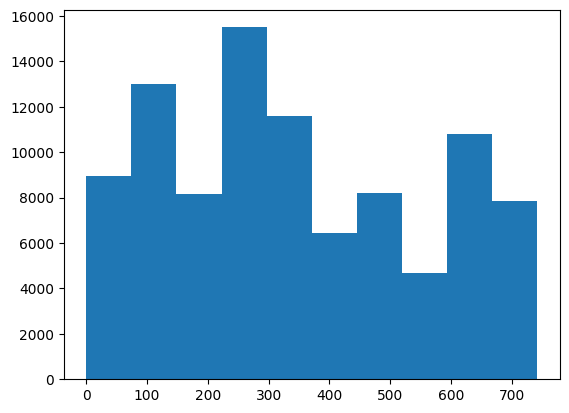

In [41]:
plot.figure()

plot.hist(gt_assignments)

plot.show()

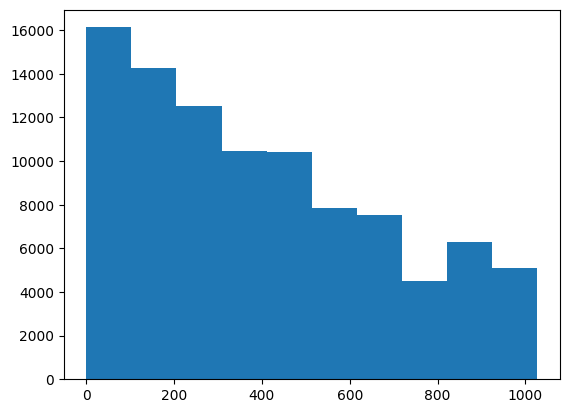

In [42]:
plot.figure()

plot.hist(lv_assignments)

plot.show()

95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
Runs found : 48
Mean score : 6794.9792
95% CI     : [6071.4000, 7807.6500]


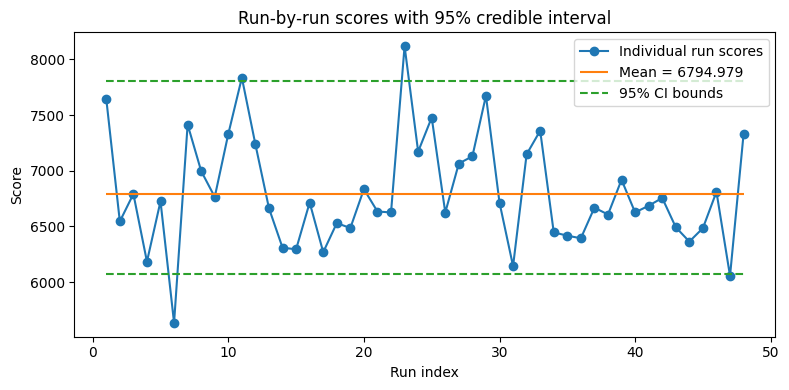

In [43]:
scores = []

for i in range(48):
    pca_cluster_assignment_dict = np.load(f"runs/pca_cluster_assignment_dict_tuned_{i+1}.npy", allow_pickle=True).item()
    shared_root_ids = list(set(root_id_type_dict.keys())
                       .intersection(set(pca_cluster_assignment_dict.keys())))
    gt_assignments = np.array([cluster_string_to_cid[root_id_type_dict[root_id]] for root_id in shared_root_ids])
    pca_assignments = np.array([pca_cluster_assignment_dict[root_id] for root_id in shared_root_ids])
    score_pca, _ = compare_two_assignments(gt_assignments, pca_assignments)
    scores.append(score_pca)
    
scores = np.array(scores)
mean_score = scores.mean()
lower, upper = np.percentile(scores, [2.5, 97.5])

print(f"Runs found : {len(scores)}")
print(f"Mean score : {mean_score:.4f}")
print(f"95% CI     : [{lower:.4f}, {upper:.4f}]")

runs = np.arange(1, len(scores) + 1)
plt.figure(figsize=(8,4))
plt.plot(runs, scores, 'o-', label="Individual run scores")
plt.hlines(mean_score, runs[0], runs[-1],
           colors='C1', linestyles='-', label=f"Mean = {mean_score:.3f}")
plt.hlines([lower, upper], runs[0], runs[-1],
           colors='C2', linestyles='--', label="95% CI bounds")
plt.xlabel("Run index")
plt.ylabel("Score")
plt.title("Run‑by‑run scores with 95% credible interval")
plt.legend()
plt.tight_layout()
plt.show()

In [44]:
std_score = scores.std(ddof=1)
std_score

np.float64(494.1207746920478)

95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
Runs found : 10
Mean score : 20771.7000
95% CI     : [19525.7500, 22427.6000]


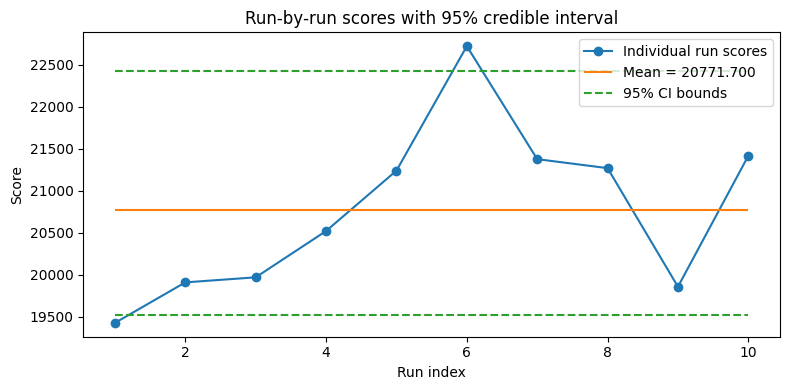

In [45]:
scores_wsbm = []

for i in range(10):
    # wsbm_cluster_assignment_dict = np.load(f"runs_wsbm/sbm_{i}/cluster_assignment_dict.npy", allow_pickle=True).item()

    with open(f'runs_wsbm/sbm_{i}/cluster_assignment_dict.json', 'r') as f:
        wsbm_cluster_assignment_dict = json.load(f)
    wsbm_cluster_assignment_dict = {int(k): v for k, v in wsbm_cluster_assignment_dict.items()}

    shared_root_ids = list(set(root_id_type_dict.keys())
                       .intersection(set(wsbm_cluster_assignment_dict.keys())))
    gt_assignments = np.array([cluster_string_to_cid[root_id_type_dict[root_id]] for root_id in shared_root_ids])
    wsbm_assignments = np.array([wsbm_cluster_assignment_dict[root_id] for root_id in shared_root_ids])
    score_wsbm, _ = compare_two_assignments(gt_assignments, wsbm_assignments)
    scores_wsbm.append(score_wsbm)
    
scores_wsbm = np.array(scores_wsbm)
mean_score = scores_wsbm.mean()
lower_wsbm, upper_wsbm = np.percentile(scores_wsbm, [2.5, 97.5])

print(f"Runs found : {len(scores_wsbm)}")
print(f"Mean score : {mean_score:.4f}")
print(f"95% CI     : [{lower_wsbm:.4f}, {upper_wsbm:.4f}]")

runs = np.arange(1, len(scores_wsbm) + 1)
plt.figure(figsize=(8,4))
plt.plot(runs, scores_wsbm, 'o-', label="Individual run scores")
plt.hlines(mean_score, runs[0], runs[-1],
           colors='C1', linestyles='-', label=f"Mean = {mean_score:.3f}")
plt.hlines([lower_wsbm, upper_wsbm], runs[0], runs[-1],
           colors='C2', linestyles='--', label="95% CI bounds")
plt.xlabel("Run index")
plt.ylabel("Score")
plt.title("Run‑by‑run scores with 95% credible interval")
plt.legend()
plt.tight_layout()
plt.show()

95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
Runs found : 49
Mean score : 17527.1429
95% CI     : [15033.6000, 21537.2000]


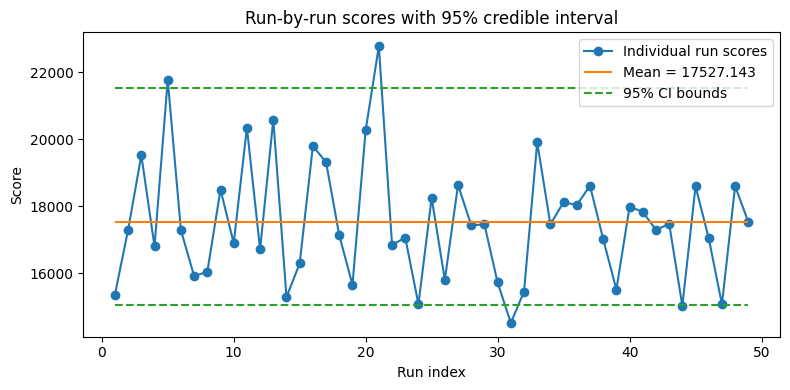

In [46]:
scores_sbm = []

for i in range(49):
    sbm_cluster_assignment_dict = np.load(f"runs_sbm/sbm_{i}/cluster_assignment_dict.npy", allow_pickle=True).item()
    shared_root_ids = list(set(root_id_type_dict.keys())
                       .intersection(set(sbm_cluster_assignment_dict.keys())))
    gt_assignments = np.array([cluster_string_to_cid[root_id_type_dict[root_id]] for root_id in shared_root_ids])
    sbm_assignments = np.array([sbm_cluster_assignment_dict[root_id] for root_id in shared_root_ids])
    score_sbm, _ = compare_two_assignments(gt_assignments, sbm_assignments)
    scores_sbm.append(score_sbm)
    
scores_sbm = np.array(scores_sbm)
mean_score = scores_sbm.mean()
lower_sbm, upper_sbm = np.percentile(scores_sbm, [2.5, 97.5])

print(f"Runs found : {len(scores_sbm)}")
print(f"Mean score : {mean_score:.4f}")
print(f"95% CI     : [{lower_sbm:.4f}, {upper_sbm:.4f}]")

runs = np.arange(1, len(scores_sbm) + 1)
plt.figure(figsize=(8,4))
plt.plot(runs, scores_sbm, 'o-', label="Individual run scores")
plt.hlines(mean_score, runs[0], runs[-1],
           colors='C1', linestyles='-', label=f"Mean = {mean_score:.3f}")
plt.hlines([lower_sbm, upper_sbm], runs[0], runs[-1],
           colors='C2', linestyles='--', label="95% CI bounds")
plt.xlabel("Run index")
plt.ylabel("Score")
plt.title("Run‑by‑run scores with 95% credible interval")
plt.legend()
plt.tight_layout()
plt.show()

In [47]:
std_score = scores_sbm.std(ddof=1)
std_score

np.float64(1827.5729237616392)

In [48]:
np.log(20000)

np.float64(9.903487552536127)

95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
Runs found : 15
Mean score : 5244.4667
95% CI     : [4283.0000, 7240.0000]


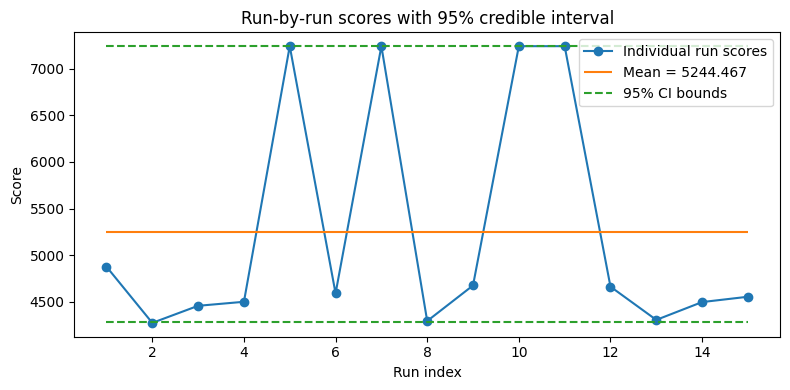

In [49]:
scores_vmog = []

for i in range(15):
    lv_dict_idx = np.load(f"vmog_runs/vmog_cluster_assignment_dict_tuned_{i+1}.npy", allow_pickle=True).item()

    vmog_cluster_assignment_dict = { idx2rid[int(idx)]: int(lbl)
                    for idx, lbl in lv_dict_idx.items()
                    if int(idx) in idx2rid }

    gt_assignments = np.array([cluster_string_to_cid[root_id_type_dict[root_id]] for root_id in shared_root_ids])
    vmog_assignments = np.array([vmog_cluster_assignment_dict[root_id] for root_id in shared_root_ids])
    score_vmog, _ = compare_two_assignments(gt_assignments, vmog_assignments)
    scores_vmog.append(score_vmog)
    
scores_vmog = np.array(scores_vmog)
mean_score_vmog = scores_vmog.mean()
lower_vmog, upper_vmog = np.percentile(scores_vmog, [2.5, 97.5])

print(f"Runs found : {len(scores_vmog)}")
print(f"Mean score : {mean_score_vmog:.4f}")
print(f"95% CI     : [{lower_vmog:.4f}, {upper_vmog:.4f}]")

runs_vmog = np.arange(1, len(scores_vmog) + 1)
plt.figure(figsize=(8,4))
plt.plot(runs_vmog, scores_vmog, 'o-', label="Individual run scores")
plt.hlines(mean_score_vmog, runs_vmog[0], runs_vmog[-1],
           colors='C1', linestyles='-', label=f"Mean = {mean_score_vmog:.3f}")
plt.hlines([lower_vmog, upper_vmog], runs_vmog[0], runs_vmog[-1],
           colors='C2', linestyles='--', label="95% CI bounds")
plt.xlabel("Run index")
plt.ylabel("Score")
plt.title("Run‑by‑run scores with 95% credible interval")
plt.legend()
plt.tight_layout()
plt.show()

In [50]:
std_score = scores_vmog.std(ddof=1)
std_score

np.float64(1255.274350585598)

95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
95145
479
Runs found : 48
Mean score : 2285.5833
9

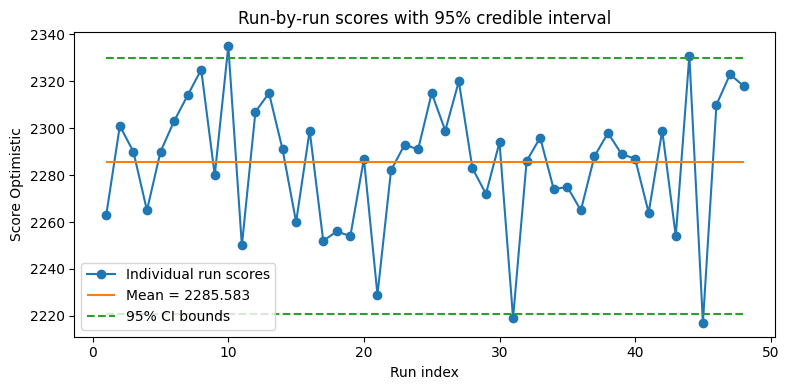

Runs found : 48
Mean score : 1282.6250
95% CI     : [1264.5250, 1299.8250]


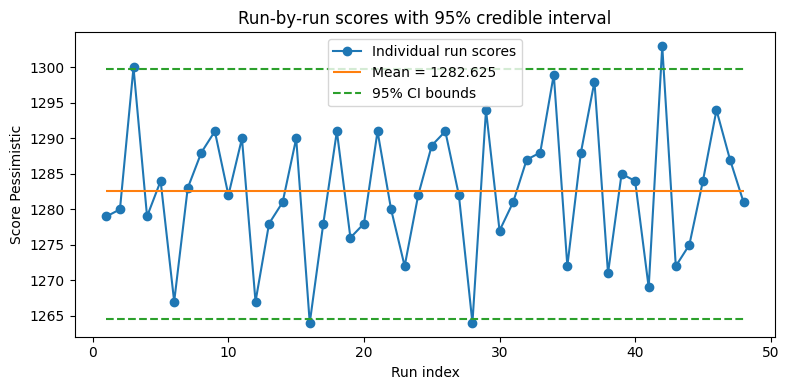

In [51]:
scores_optimistic = []
scores_pessimistic = []

for i in range(48):
    # create a random assignment by randomly permuting `target_assignment`
    random_assignment_optimistic = np.random.permutation(gt_assignments)
    random_assignment_pessimistic = np.random.randint(0, np.unique(gt_assignments).shape[0], gt_assignments.shape[0])
    
    gt_assignments = np.array([cluster_string_to_cid[root_id_type_dict[root_id]] for root_id in shared_root_ids])
    
    score_optimistic, _ = compare_two_assignments(gt_assignments, random_assignment_optimistic)
    scores_optimistic.append(score_optimistic)
    
    score_pessimistic, _ = compare_two_assignments(gt_assignments, random_assignment_pessimistic)
    scores_pessimistic.append(score_pessimistic)
    
scores_optimistic = np.array(scores_optimistic)
mean_score_optimistic = scores_optimistic.mean()
lower_optimistic, upper_optimistic = np.percentile(scores_optimistic, [2.5, 97.5])

print(f"Runs found : {len(scores_optimistic)}")
print(f"Mean score : {mean_score_optimistic:.4f}")
print(f"95% CI     : [{lower_optimistic:.4f}, {upper_optimistic:.4f}]")

runs_optimistic = np.arange(1, len(scores_optimistic) + 1)
plt.figure(figsize=(8,4))
plt.plot(runs_optimistic, scores_optimistic, 'o-', label="Individual run scores")
plt.hlines(mean_score_optimistic, runs_optimistic[0], runs_optimistic[-1],
           colors='C1', linestyles='-', label=f"Mean = {mean_score_optimistic:.3f}")
plt.hlines([lower_optimistic, upper_optimistic], runs_optimistic[0], runs_optimistic[-1],
           colors='C2', linestyles='--', label="95% CI bounds")
plt.xlabel("Run index")
plt.ylabel("Score Optimistic")
plt.title("Run‑by‑run scores with 95% credible interval")
plt.legend()
plt.tight_layout()
plt.show()

scores_pessimistic = np.array(scores_pessimistic)
mean_score_pessimistic = scores_pessimistic.mean()
lower_pessimistic, upper_pessimistic = np.percentile(scores_pessimistic, [2.5, 97.5])

print(f"Runs found : {len(scores_pessimistic)}")
print(f"Mean score : {mean_score_pessimistic:.4f}")
print(f"95% CI     : [{lower_pessimistic:.4f}, {upper_pessimistic:.4f}]")

runs_pessimistic = np.arange(1, len(scores_pessimistic) + 1)
plt.figure(figsize=(8,4))
plt.plot(runs_pessimistic, scores_pessimistic, 'o-', label="Individual run scores")
plt.hlines(mean_score_pessimistic, runs_pessimistic[0], runs_pessimistic[-1],
           colors='C1', linestyles='-', label=f"Mean = {mean_score_pessimistic:.3f}")
plt.hlines([lower_pessimistic, upper_pessimistic], runs_pessimistic[0], runs_pessimistic[-1],
           colors='C2', linestyles='--', label="95% CI bounds")
plt.xlabel("Run index")
plt.ylabel("Score Pessimistic")
plt.title("Run‑by‑run scores with 95% credible interval")
plt.legend()
plt.tight_layout()
plt.show()

In [52]:
std_score = scores_pessimistic.std(ddof=1)
std_score

np.float64(9.379980946312816)

In [53]:
std_score = runs_optimistic.std(ddof=1)
std_score

np.float64(14.0)

In [54]:
# means = [np.mean(scores), np.mean(scores_optimistic), np.mean(scores_pessimistic)]

# # Create the figure and axes
# fig, ax = plt.subplots(figsize=(10, 6))

# # Create boxplots
# data = [scores, scores_optimistic, scores_pessimistic]
# box = ax.boxplot(data, patch_artist=True, positions=[1, 2, 3])

# # Customize boxplot colors
# colors = ['lightblue', 'lightgreen', 'lightsalmon']
# for patch, color in zip(box['boxes'], colors):
#     patch.set_facecolor(color)

# # Add means as diamond markers
# ax.scatter([1, 2, 3], means, marker='D', color='red', s=80, zorder=3, label='Mean')

# # Add credible intervals as error bars
# ax.errorbar([1, 2, 3], means, yerr=[
#                 [lower, lower_optimistic, lower_pessimistic],
#                 [upper, lower_optimistic, upper_pessimistic]
#             ], fmt='none', color='black', capsize=5, label='95% CI')

# # Add labels and title
# ax.set_ylabel('Scores')
# ax.set_title('Comparison of Score Distributions')
# ax.set_xticks([1, 2, 3])
# ax.set_xticklabels(['PCA Kmeans', 'Random Optimistic', 'Random Pessimistic'])

# # Add grid lines
# ax.yaxis.grid(True, linestyle='--', alpha=0.7)

# # Add legend
# ax.legend()

# # Show the plot
# plt.tight_layout()
# plt.show()

In [55]:
np.log(6775.0208)

np.float64(8.82099771585389)

In [56]:
means = [np.mean(scores), np.mean(scores_vmog), np.mean(scores_optimistic), np.mean(scores_pessimistic)]

In [57]:
print(lower)

6071.4


In [58]:
print(means)

[np.float64(6794.979166666667), np.float64(5244.466666666666), np.float64(2285.5833333333335), np.float64(1282.625)]


In [59]:
print(lower_pessimistic)

1264.525


In [60]:
upper

np.float64(7807.65)

In [61]:
[-means[0] + upper, -means[1] + upper_vmog, -means[2] + lower_optimistic, -means[3] + upper_pessimistic]

[np.float64(1012.6708333333327),
 np.float64(1995.5333333333338),
 np.float64(-64.83333333333348),
 np.float64(17.200000000000045)]

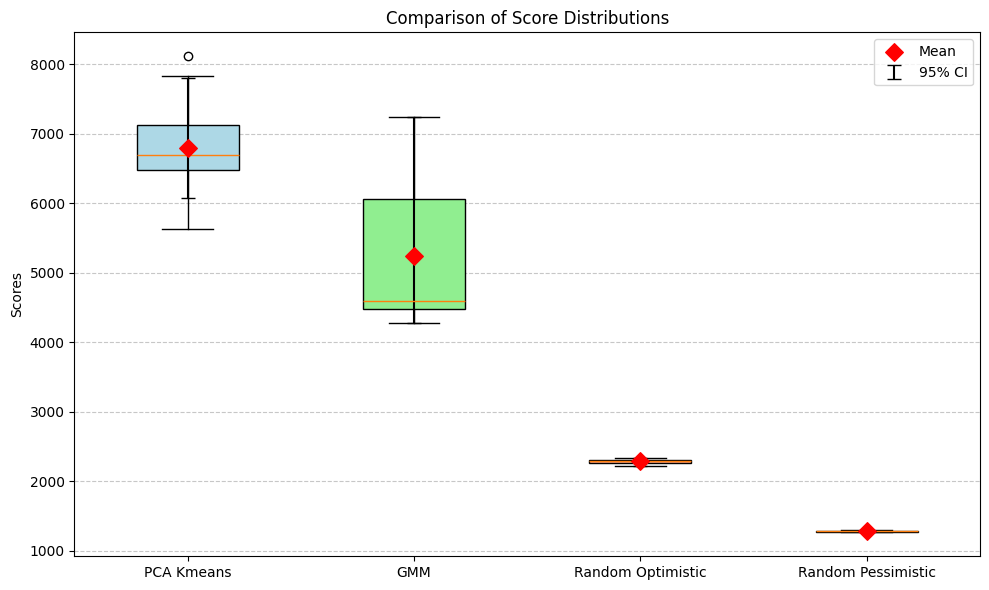

In [62]:
means = [np.mean(scores), np.mean(scores_vmog), np.mean(scores_optimistic), np.mean(scores_pessimistic)]

# Create the figure and axes
fig, ax = plt.subplots(figsize=(10, 6))

# Create boxplots
data = [scores, scores_vmog, scores_optimistic, scores_pessimistic]
box = ax.boxplot(data, patch_artist=True, positions=[1, 2, 3, 4])

# Customize boxplot colors
colors = ['lightblue', 'lightgreen', 'lightsalmon', 'lavender']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

# Add means as diamond markers
ax.scatter([1, 2, 3, 4], means, marker='D', color='red', s=80, zorder=3, label='Mean')

# Add credible intervals as error bars
ax.errorbar([1, 2, 3, 4], means, yerr=[
                [means[0] - lower, means[1] - lower_vmog, means[2] - lower_optimistic, means[3] - lower_pessimistic],
                [-means[0] + upper, -means[1] + upper_vmog, -means[2] + upper_optimistic, -means[3] + upper_pessimistic]
            ], fmt='none', color='black', capsize=5, label='95% CI')

# Add labels and title
ax.set_ylabel('Scores')
ax.set_title('Comparison of Score Distributions')
ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels(['PCA Kmeans', 'GMM', 'Random Optimistic', 'Random Pessimistic'])

# Add grid lines
ax.yaxis.grid(True, linestyle='--', alpha=0.7)

# Add legend
ax.legend()

# Show the plot
plt.tight_layout()
plt.show()

In [63]:
my_list = [95000] * 48

In [64]:
gt = np.array(my_list)
gt

array([95000, 95000, 95000, 95000, 95000, 95000, 95000, 95000, 95000,
       95000, 95000, 95000, 95000, 95000, 95000, 95000, 95000, 95000,
       95000, 95000, 95000, 95000, 95000, 95000, 95000, 95000, 95000,
       95000, 95000, 95000, 95000, 95000, 95000, 95000, 95000, 95000,
       95000, 95000, 95000, 95000, 95000, 95000, 95000, 95000, 95000,
       95000, 95000, 95000])

In [65]:
np.mean(scores_pessimistic)

np.float64(1282.625)

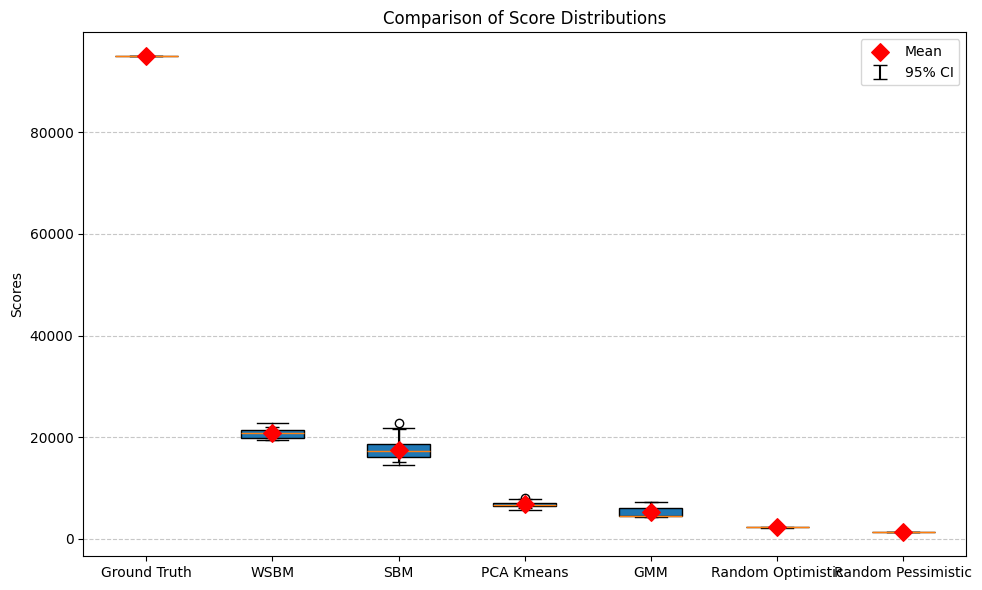

In [66]:
means = [95000, np.mean(scores_wsbm), np.mean(scores_sbm), np.mean(scores), np.mean(scores_vmog), np.mean(scores_optimistic), np.mean(scores_pessimistic)]

# Create the figure and axes
fig, ax = plt.subplots(figsize=(10, 6))

# Create boxplots
data = [gt, scores_wsbm, scores_sbm, scores, scores_vmog, scores_optimistic, scores_pessimistic]
box = ax.boxplot(data, patch_artist=True, positions=[1, 2, 3, 4, 5, 6, 7])

# Customize boxplot colors
# colors = ['red', 'lightblue', 'lightgreen', 'lightsalmon', 'lavender']
# for patch, color in zip(box['boxes'], colors):
#     patch.set_facecolor(color)

# Add means as diamond markers
ax.scatter([1, 2, 3, 4, 5, 6, 7], means, marker='D', color='red', s=80, zorder=3, label='Mean')

# Add credible intervals as error bars
ax.errorbar([1, 2, 3, 4, 5, 6, 7], means, yerr=[
                [0, means[1] - lower_wsbm, means[2] - lower_sbm, means[3] - lower, means[4] - lower_vmog, means[5] - lower_optimistic, means[6] - lower_pessimistic],
                [0, means[1] - lower_wsbm, -means[2] + upper_sbm, -means[3] + upper, -means[4] + upper_vmog, -means[5] + upper_optimistic, -means[6] + upper_pessimistic]
            ], fmt='none', color='black', capsize=5, label='95% CI')

# Add labels and title
ax.set_ylabel('Scores')
ax.set_title('Comparison of Score Distributions')
ax.set_xticks([1, 2, 3, 4, 5, 6, 7])
ax.set_xticklabels(['Ground Truth', 'WSBM', 'SBM', 'PCA Kmeans', 'GMM', 'Random Optimistic', 'Random Pessimistic'])

# Add grid lines
ax.yaxis.grid(True, linestyle='--', alpha=0.7)

# Add legend
ax.legend()

# Show the plot

plt.tight_layout()

plt.show()


C:\Users\ROG\AppData\Local\Temp\ipykernel_21668\707618768.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


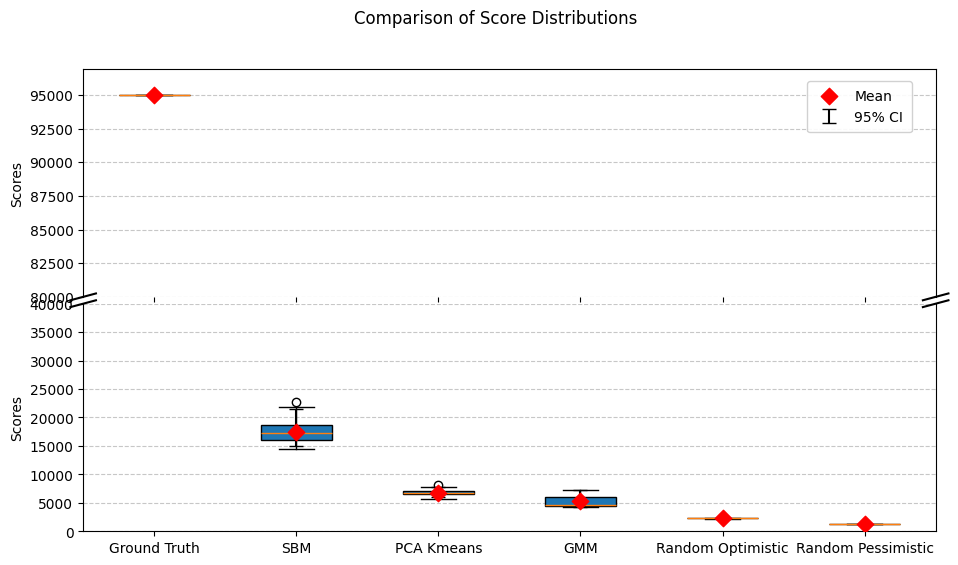

In [67]:
import numpy as np
import matplotlib.pyplot as plt

means = [95000, np.mean(scores_sbm), np.mean(scores), np.mean(scores_vmog),
         np.mean(scores_optimistic), np.mean(scores_pessimistic)]

positions = [1, 2, 3, 4, 5, 6]
labels = ['Ground Truth', 'SBM', 'PCA Kmeans', 'GMM', 'Random Optimistic', 'Random Pessimistic']
data = [gt, scores_sbm, scores, scores_vmog, scores_optimistic, scores_pessimistic]

ymax_candidates = []
for arr in data:
    if len(arr) > 0:
        ymax_candidates.append(np.nanmax(np.asarray(arr)))
ymax_candidates += [m for m in means if m is not None]
ymax_candidates += [upper_sbm, upper, upper_vmog, upper_optimistic, upper_pessimistic]
ymax = max(ymax_candidates) * 1.02  
fig, (ax_hi, ax_lo) = plt.subplots(
    2, 1, sharex=True, figsize=(11, 6),
    gridspec_kw={'height_ratios': [1, 1], 'hspace': 0.03}
)

def draw_on(ax, add_legend=False):
    box = ax.boxplot(data, patch_artist=True, positions=positions)

    ax.scatter(positions, means, marker='D', color='red', s=70, zorder=3,
               label=('Mean' if add_legend else None))

    # 95% CI
    ax.errorbar(
        positions, means,
        yerr=[
            [0, means[1] - lower_sbm, means[2] - lower, means[3] - lower_vmog, means[4] - lower_optimistic, means[5] - lower_pessimistic],
            [0, -means[1] + upper_sbm, -means[2] + upper, -means[3] + upper_vmog, -means[4] + upper_optimistic, -means[5] + upper_pessimistic]
        ],
        fmt='none', color='black', capsize=5,
        label=('95% CI' if add_legend else None)
    )
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)

draw_on(ax_hi, add_legend=True)
draw_on(ax_lo, add_legend=False)

ax_lo.set_ylim(0, 40000)       
ax_hi.set_ylim(80000, ymax)     

for ax, which in [(ax_hi, 'bottom'), (ax_lo, 'top')]:
    ax.spines[which].set_visible(False)
ax_hi.tick_params(labeltop=False)
ax_lo.xaxis.tick_bottom()

d = .015 
kwargs_hi = dict(transform=ax_hi.transAxes, color='k', clip_on=False)
ax_hi.plot((-d, +d), (-d, +d), **kwargs_hi)
ax_hi.plot((1 - d, 1 + d), (-d, +d), **kwargs_hi)
kwargs_lo = dict(transform=ax_lo.transAxes, color='k', clip_on=False)
ax_lo.plot((-d, +d), (1 - d, 1 + d), **kwargs_lo)
ax_lo.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs_lo)

ax_lo.set_xticks(positions)
ax_lo.set_xticklabels(labels, rotation=0)
ax_lo.set_ylabel('Scores')
ax_hi.set_ylabel('Scores')

fig.suptitle('Comparison of Score Distributions (broken y-axis)')


fig.suptitle('Comparison of Score Distributions')

leg = ax_hi.legend(
    loc='upper right',
    bbox_to_anchor=(0.98, 0.98),  
    frameon=True,
    framealpha=0.9,
    borderpad=0.6,
    fontsize=10
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()


In [68]:
# should we be expecting higher variance from GMM?

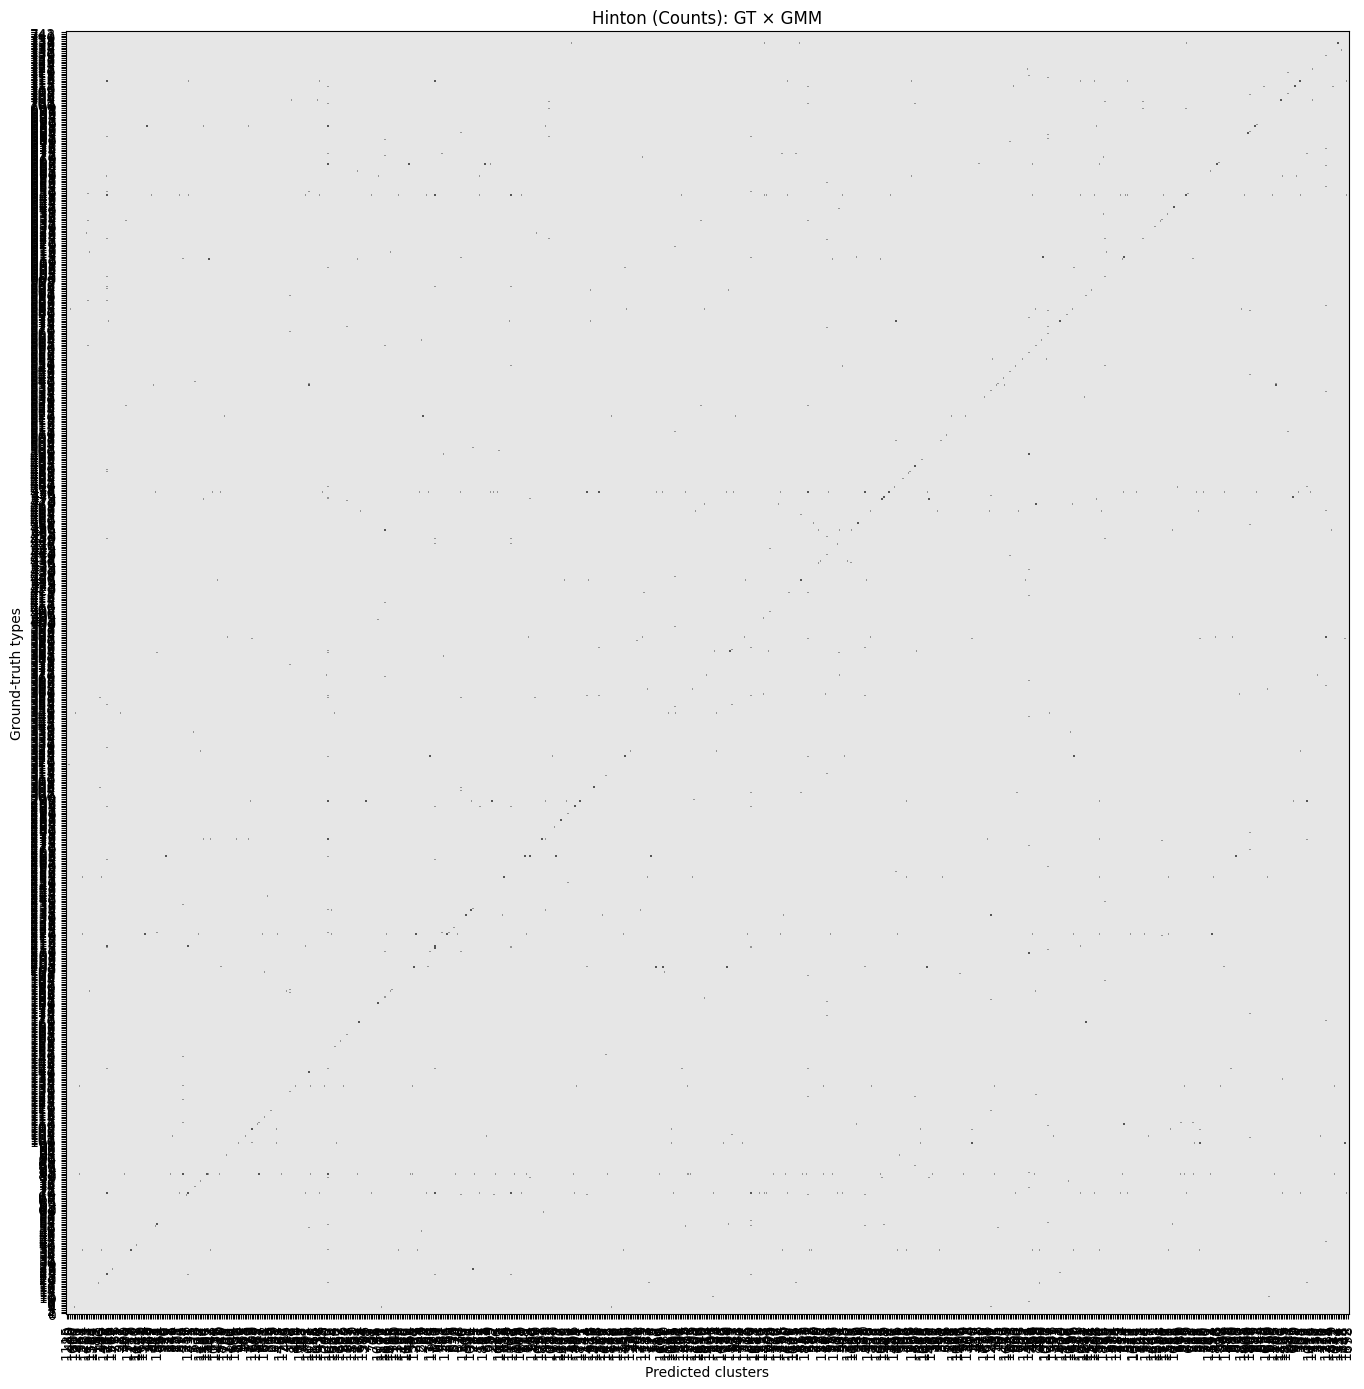

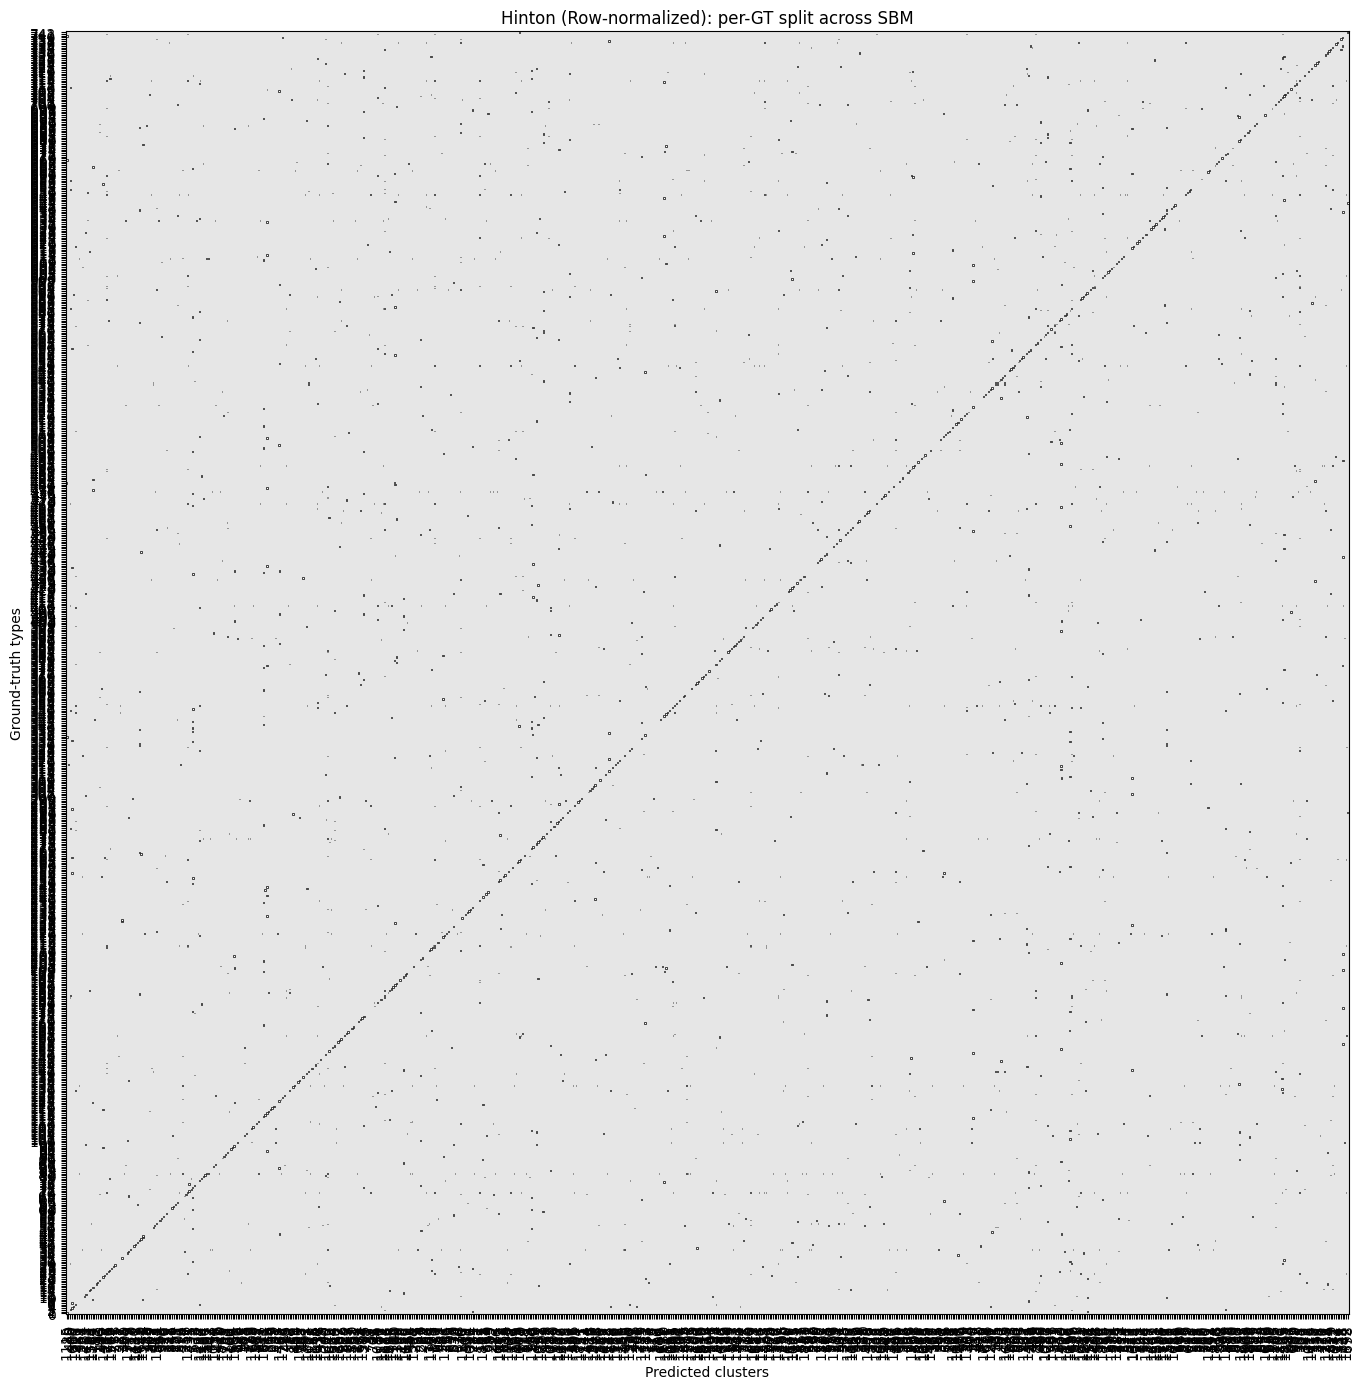

array([[ 2,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0, 16, ...,  0,  0,  0],
       ...,
       [ 2,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  8,  0],
       [ 0,  0,  0, ...,  0,  0, 10]], shape=(743, 743))

In [69]:
import numpy as np
import matplotlib.pyplot as plt
# from scipy.optimize import linear_sum_assignment

def make_consecutive_labels(y):
    y = np.asarray(y)
    uniq = np.unique(y)
    remap = {v: i for i, v in enumerate(uniq)}
    return np.array([remap[v] for v in y]), [str(v) for v in uniq]

def contingency_matrix(y_true, y_pred):
    C = np.zeros((int(y_true.max())+1, int(y_pred.max())+1), dtype=np.int64)
    np.add.at(C, (y_true, y_pred), 1)
    return C

def align_columns_by_hungarian(C):
    r, c = linear_sum_assignment(-C)
    return C[:, c], c

def hinton(ax, M, max_weight=None):
    ax.cla()
    h, w = M.shape
    if max_weight is None:
        max_weight = 2 ** np.ceil(np.log2(np.abs(M).max() if M.size else 1))
    ax.set_aspect('equal', 'box')
    ax.set_facecolor('0.9')
    ax.set_xlim(0, w); ax.set_ylim(0, h)
    for (i, j), v in np.ndenumerate(M):
        if v <= 0: continue
        s = np.sqrt(v / max_weight)
        rect = plt.Rectangle((j+0.5-s/2, i+0.5-s/2), s, s,
                             facecolor='white', edgecolor='black', linewidth=0.5)
        ax.add_patch(rect)

def plot_hinton_gt_vs_pred(y_gt, y_pred, row_names=None, col_names=None,
                           normalize='none', align=True, title='Hinton'):
    C = contingency_matrix(y_gt, y_pred)
    if align:
        C, col_perm = align_columns_by_hungarian(C)
        if col_names is not None:
            col_names = [col_names[j] for j in col_perm]
    C_plot = C.astype(float)
    if normalize == 'row':
        rs = C_plot.sum(axis=1, keepdims=True); rs[rs==0]=1
        C_plot = C_plot / rs
    elif normalize == 'col':
        cs = C_plot.sum(axis=0, keepdims=True); cs[cs==0]=1
        C_plot = C_plot / cs

    # fig, ax = plt.subplots(figsize=(min(18, 2+0.5*C.shape[1]), min(14, 2+0.5*C.shape[0])))
    fig, ax = plt.subplots(
    figsize=(min(18, 2+0.5*C.shape[1]),  # width ∝ #cols
             min(14, 2+0.5*C.shape[0]))  # height ∝ #rows
)

    hinton(ax, C_plot)
    ax.set_title(title); ax.set_xlabel('Predicted clusters'); ax.set_ylabel('Ground-truth types')
    ax.set_xticks(np.arange(C.shape[1]) + 0.5)
    ax.set_yticks(np.arange(C.shape[0]) + 0.5)
    ax.set_xticklabels(col_names if col_names is not None else [f'c{j}' for j in range(C.shape[1])], rotation=90)
    ax.set_yticklabels(row_names if row_names is not None else [f't{i}' for i in range(C.shape[0])])
    plt.tight_layout(); plt.show()
    return C

#1 compute gt
gt_assignments = np.array([cluster_string_to_cid[root_id_type_dict[rid]] for rid in shared_root_ids])

#2 random optimistic label
random_assignment_optimistic = np.random.permutation(gt_assignments)

#3 transfer to continuous int label
y_gt_i, gt_names = make_consecutive_labels(gt_assignments)
y_ro_i, ro_names = make_consecutive_labels(sbm_assignments)

#4 draw count-based hinton
plot_hinton_gt_vs_pred(
    y_gt_i, y_ro_i,
    row_names=gt_names, col_names=ro_names,
    normalize='none', align=True,
    title='Hinton (Counts): GT × GMM'
)

#5 draw row-normalized hinton
plot_hinton_gt_vs_pred(
    y_gt_i, y_ro_i,
    row_names=gt_names, col_names=ro_names,
    normalize='row', align=True,
    title='Hinton (Row-normalized): per-GT split across SBM'
)

In [70]:
print("Number of ground-truth types:", len(np.unique(y_gt_i)))
print("Number of predicted clusters:", len(np.unique(y_ro_i)))

Number of ground-truth types: 743
Number of predicted clusters: 1191


In [71]:
with open("root_id_to_index_mapping.json", "r") as f:
    rid2idx = json.load(f)                     
idx2rid = {int(v): int(k) for k, v in rid2idx.items()}

lv_dict_idx = np.load('vmog_runs/vmog_cluster_assignment_dict_tuned_2.npy', allow_pickle=True).item()

lv_cluster_assignment_dict = { idx2rid[int(idx)]: int(lbl)
                 for idx, lbl in lv_dict_idx.items()
                 if int(idx) in idx2rid }

shared_root_ids = list(set(root_id_type_dict.keys())
                       .intersection(set(pca_cluster_assignment_dict.keys()))
                                     .intersection(set(lv_cluster_assignment_dict.keys()))
                                        .intersection(set(sbm_cluster_assignment_dict.keys())))


lv_assignments = np.array([lv_cluster_assignment_dict[root_id] for root_id in shared_root_ids])
y_KM_i, names = make_consecutive_labels(lv_assignments)
print("Number of predicted clusters:", len(np.unique(y_KM_i)))

Number of predicted clusters: 542


In [72]:
unique_labels = np.unique(lv_assignments)
print("Unique cluster IDs:", unique_labels[:20], "...")
print("Total clusters present:", len(unique_labels))

Unique cluster IDs: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19] ...
Total clusters present: 542


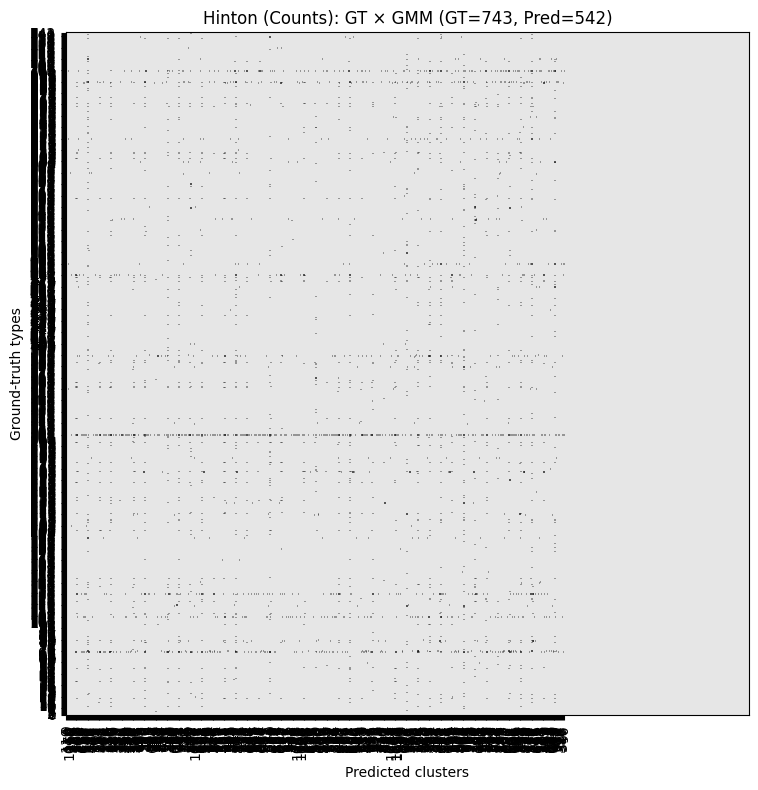

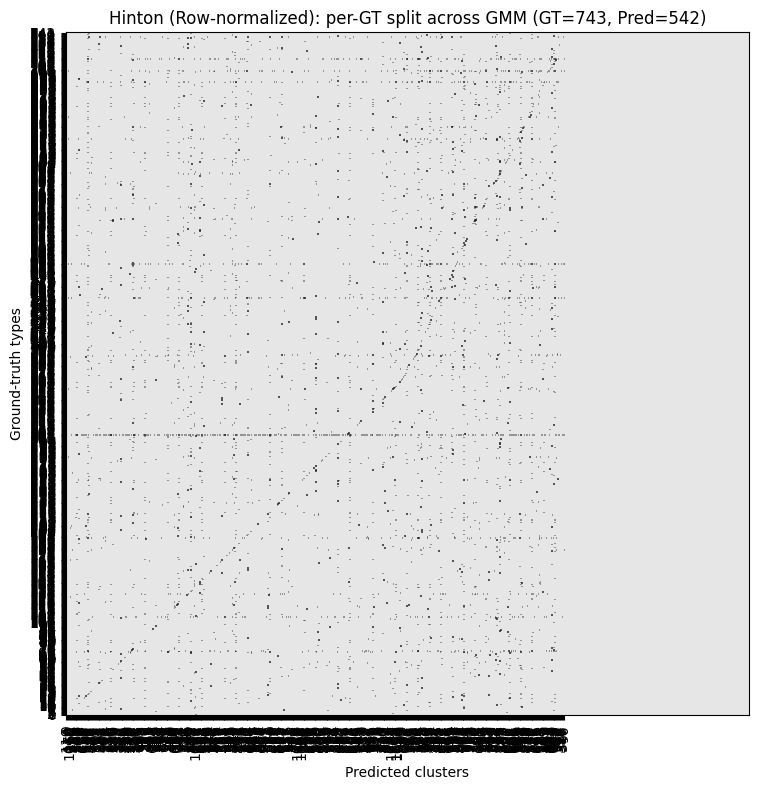

array([[ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0, 11, ...,  0,  0,  0],
       ...,
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  8],
       [ 0,  0,  0, ...,  0,  0,  0]], shape=(743, 542))

In [73]:
import numpy as np
import matplotlib.pyplot as plt
# from scipy.optimize import linear_sum_assignment

def make_consecutive_labels(y):
    y = np.asarray(y)
    uniq = np.unique(y)
    remap = {v: i for i, v in enumerate(uniq)}
    return np.array([remap[v] for v in y]), [str(v) for v in uniq]

def contingency_matrix(y_true, y_pred):
    C = np.zeros((int(y_true.max())+1, int(y_pred.max())+1), dtype=np.int64)
    np.add.at(C, (y_true, y_pred), 1)
    return C

def align_columns_by_hungarian(C):
    r, c = linear_sum_assignment(-C)
    return C[:, c], c

def hinton(ax, M, max_weight=None):
    ax.cla()
    h, w = M.shape
    if max_weight is None:
        max_weight = 2 ** np.ceil(np.log2(np.abs(M).max() if M.size else 1))
    ax.set_aspect('equal', 'box')
    ax.set_facecolor('0.9')
    ax.set_xlim(0, w); ax.set_ylim(0, h)
    for (i, j), v in np.ndenumerate(M):
        if v <= 0: continue
        s = np.sqrt(v / max_weight)
        rect = plt.Rectangle((j+0.5-s/2, i+0.5-s/2), s, s,
                             facecolor='white', edgecolor='black', linewidth=0.5)
        ax.add_patch(rect)
def plot_hinton_gt_vs_pred(y_gt, y_pred, row_names=None, col_names=None,
                           normalize='none', align=True, title='Hinton',
                           pad_to_square=True):
    C = contingency_matrix(y_gt, y_pred)
    if align:
        C, col_perm = align_columns_by_hungarian(C)
        if col_names is not None:
            col_names = [col_names[j] for j in col_perm]
    C_plot = C.astype(float)
    if normalize == 'row':
        rs = C_plot.sum(axis=1, keepdims=True); rs[rs==0] = 1
        C_plot = C_plot / rs
    elif normalize == 'col':
        cs = C_plot.sum(axis=0, keepdims=True); cs[cs==0] = 1
        C_plot = C_plot / cs

    # --- pad to square ---
    if pad_to_square:
        n = max(C_plot.shape)
        S = np.zeros((n, n), dtype=C_plot.dtype)
        S[:C_plot.shape[0], :C_plot.shape[1]] = C_plot
    else:
        S = C_plot

    # --- make figure square ---
    fig, ax = plt.subplots(figsize=(8, 8))  # 正方形画布
    hinton(ax, S)
    ax.set_title(f"{title} (GT={C.shape[0]}, Pred={C.shape[1]})")
    ax.set_xlabel('Predicted clusters'); ax.set_ylabel('Ground-truth types')

    # 只显示真实的刻度，不显示填充部分
    ax.set_xticks(np.arange(C.shape[1]) + 0.5)
    ax.set_yticks(np.arange(C.shape[0]) + 0.5)
    ax.set_xticklabels(
        col_names if col_names is not None else [f'c{j}' for j in range(C.shape[1])],
        rotation=90
    )
    ax.set_yticklabels(
        row_names if row_names is not None else [f't{i}' for i in range(C.shape[0])]
    )
    ax.set_xlim(0, S.shape[1]); ax.set_ylim(0, S.shape[0])

    plt.tight_layout()
    plt.show()
    return C


#1 compute gt
gt_assignments = np.array([cluster_string_to_cid[root_id_type_dict[rid]] for rid in shared_root_ids])

#2 random optimistic label
random_assignment_optimistic = np.random.permutation(gt_assignments)

#3 transfer to continuous int label
y_gt_i, gt_names = make_consecutive_labels(gt_assignments)
y_ro_i, ro_names = make_consecutive_labels(lv_assignments)

#4 draw count-based hinton
plot_hinton_gt_vs_pred(
    y_gt_i, y_ro_i,
    row_names=gt_names, col_names=ro_names,
    normalize='none', align=True,
    title='Hinton (Counts): GT × GMM'
)

#5 draw row-normalized hinton
plot_hinton_gt_vs_pred(
    y_gt_i, y_ro_i,
    row_names=gt_names, col_names=ro_names,
    normalize='row', align=True,
    title='Hinton (Row-normalized): per-GT split across GMM'
)

In [74]:
a = 2695/371
a

7.264150943396227

In [75]:
y = [21, 59, 25, 127]
x = [4, 9, 7, 15]
t = 0
for i in range(len(y)):
    t += (y[i] - x[i]*a)**2

t/4

274.7783018867925

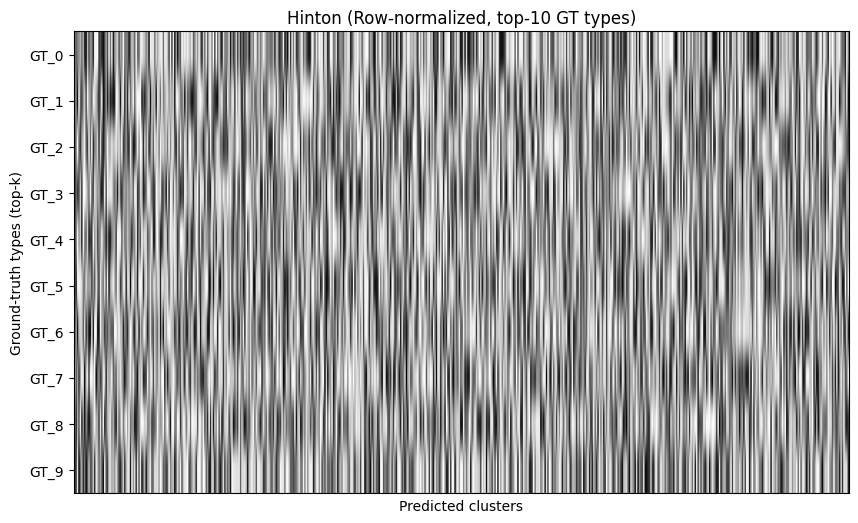

In [76]:
import matplotlib.pyplot as plt
import numpy as np

# Let's simulate a similar Hinton diagram with fewer labels (top-k GT types)
# Since we don't have the actual plotting code yet, I'll create a function that
# trims the matrix to top-k rows for visualization.

def plot_hinton_topk(matrix, gt_labels, pred_labels, top_k=10):
    """
    Plot a simplified Hinton diagram with only the top_k ground-truth rows.
    
    Args:
        matrix (np.ndarray): Row-normalized GT x Pred matrix.
        gt_labels (list): Ground-truth type labels.
        pred_labels (list): Predicted cluster labels.
        top_k (int): Number of top GT types to show.
    """
    # Select top_k rows (e.g., first top_k)
    matrix_topk = matrix[:top_k, :]
    gt_labels_topk = gt_labels[:top_k]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.imshow(matrix_topk, cmap="Greys", aspect="auto")
    
    # Set ticks
    ax.set_yticks(np.arange(top_k))
    ax.set_yticklabels(gt_labels_topk)
    ax.set_xticks([])  # avoid cluttered x-axis
    ax.set_xlabel("Predicted clusters")
    ax.set_ylabel("Ground-truth types (top-k)")
    ax.set_title(f"Hinton (Row-normalized, top-{top_k} GT types)")
    
    plt.show()

# Example: simulate a 743x542 matrix and visualize top-10 rows
np.random.seed(0)
matrix = np.random.rand(743, 542)
matrix = matrix / matrix.sum(axis=1, keepdims=True)  # row normalize
gt_labels = [f"GT_{i}" for i in range(743)]
pred_labels = [f"Pred_{j}" for j in range(542)]

plot_hinton_topk(matrix, gt_labels, pred_labels, top_k=10)


In [77]:
def plot_hinton_gt_vs_pred(
    y_gt, y_pred, row_names=None, col_names=None,
    normalize='none', align=True, title='Hinton',
    pad_to_square=True,
    top_k_rows=None, top_k_cols=None, top_by='count', keep_rest_as_other=True
):
    """
    新增特性：
      - top_k_rows / top_k_cols：只显示Top-K行/列，其他可合并为'Other'
      - top_by: 'count' 或 'mass'
    """

    # --- 原流程：构造与可选对齐 ---
    C = contingency_matrix(y_gt, y_pred)
    if align:
        try:
            from scipy.optimize import linear_sum_assignment
            C, col_perm = align_columns_by_hungarian(C)
            if col_names is not None:
                col_names = [col_names[j] for j in col_perm]
        except Exception:
            # 没有scipy或对齐失败则忽略
            pass

    # 初始标签兜底
    if row_names is None:
        row_names = [f't{i}' for i in range(C.shape[0])]
    if col_names is None:
        col_names = [f'c{j}' for j in range(C.shape[1])]

    C_plot = C.astype(float)

    # 归一化（如果需要）
    if normalize == 'row':
        rs = C_plot.sum(axis=1, keepdims=True); rs[rs == 0] = 1
        C_plot = C_plot / rs
    elif normalize == 'col':
        cs = C_plot.sum(axis=0, keepdims=True); cs[cs == 0] = 1
        C_plot = C_plot / cs

    # --- 选择Top-K行 ---
    if top_k_rows is not None and top_k_rows < C_plot.shape[0]:
        if top_by == 'count':
            # 用原始计数衡量行规模
            row_score = C.sum(axis=1)
        else:  # 'mass'
            row_score = C_plot.sum(axis=1)
        top_idx = np.argsort(row_score)[::-1][:top_k_rows]
        rest_idx = np.setdiff1d(np.arange(C_plot.shape[0]), top_idx)

        C_rows = C_plot[top_idx, :]
        names_rows = [row_names[i] for i in top_idx]

        if keep_rest_as_other and rest_idx.size > 0:
            other_row = C_plot[rest_idx, :].sum(axis=0, keepdims=True)
            C_rows = np.vstack([C_rows, other_row])
            names_rows.append('Other')

        C_plot = C_rows
        row_names = names_rows

    # --- 选择Top-K列 ---
    if top_k_cols is not None and top_k_cols < C_plot.shape[1]:
        if top_by == 'count':
            col_score = C.sum(axis=0)
        else:  # 'mass'
            col_score = C_plot.sum(axis=0)
        top_j = np.argsort(col_score)[::-1][:top_k_cols]
        rest_j = np.setdiff1d(np.arange(C_plot.shape[1]), top_j)

        C_cols = C_plot[:, top_j]
        names_cols = [col_names[j] for j in top_j]

        if keep_rest_as_other and rest_j.size > 0:
            other_col = C_plot[:, rest_j].sum(axis=1, keepdims=True)
            C_cols = np.hstack([C_cols, other_col])
            names_cols.append('Other')

        C_plot = C_cols
        col_names = names_cols

    # --- pad to square ---
    if pad_to_square:
        n = max(C_plot.shape)
        S = np.zeros((n, n), dtype=C_plot.dtype)
        S[:C_plot.shape[0], :C_plot.shape[1]] = C_plot
    else:
        S = C_plot

    # --- 画图（保持正方形画布） ---
    fig, ax = plt.subplots(figsize=(8, 8))
    hinton(ax, S)
    ax.set_title(f"{title} (GT={C.shape[0]}, Pred={C.shape[0]})")
    ax.set_xlabel('Predicted clusters'); ax.set_ylabel('Ground-truth types')

    # 只显示真实的刻度
    ax.set_xticks(np.arange(C_plot.shape[1]) + 0.5)
    ax.set_yticks(np.arange(C_plot.shape[0]) + 0.5)
    ax.set_xticklabels(col_names, rotation=90)
    ax.set_yticklabels(row_names)

    ax.set_xlim(0, S.shape[1]); ax.set_ylim(0, S.shape[0])
    plt.tight_layout()
    plt.show()
    return C


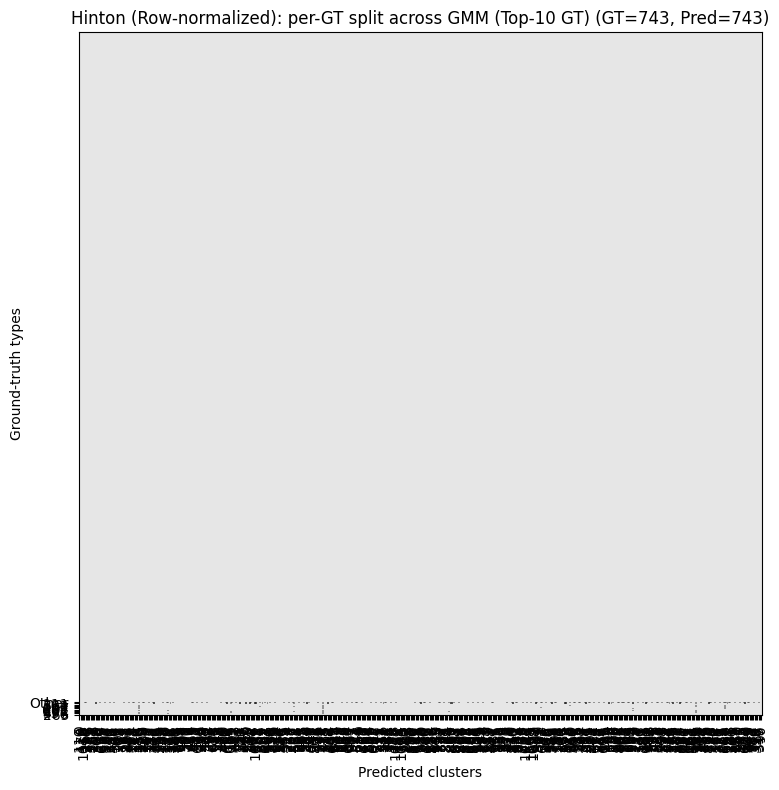

array([[ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0, 11, ...,  0,  0,  0],
       ...,
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  8],
       [ 0,  0,  0, ...,  0,  0,  0]], shape=(743, 542))

In [78]:

#1 compute gt
gt_assignments = np.array([cluster_string_to_cid[root_id_type_dict[rid]] for rid in shared_root_ids])

#2 random optimistic label
random_assignment_optimistic = np.random.permutation(gt_assignments)

#3 transfer to continuous int label
y_gt_i, gt_names = make_consecutive_labels(gt_assignments)
y_ro_i, ro_names = make_consecutive_labels(lv_assignments)

#4 draw count-based hinton
plot_hinton_gt_vs_pred(
    y_gt_i, y_ro_i,
    row_names=gt_names, col_names=ro_names,
    normalize='row', align=True,
    title='Hinton (Row-normalized): per-GT split across GMM (Top-10 GT)',
    top_k_rows=10, top_k_cols=None, top_by='count', keep_rest_as_other=True
)


In [79]:
# def plot_hinton_gt_vs_pred(
#     y_gt, y_pred, row_names=None, col_names=None,
#     normalize='none', align=True, title='Hinton',
#     pad_to_square=False,               # 关键：默认改为 False
#     top_k_rows=None, top_k_cols=None,  # 仅裁剪，不合并“Other”
#     top_by='count'                     # 'count' or 'mass'
# ):
#     C = contingency_matrix(y_gt, y_pred)

#     if align:
#         try:
#             from scipy.optimize import linear_sum_assignment
#             C, col_perm = align_columns_by_hungarian(C)
#             if col_names is not None:
#                 col_names = [col_names[j] for j in col_perm]
#         except Exception:
#             pass

#     if row_names is None:
#         row_names = [f't{i}' for i in range(C.shape[0])]
#     if col_names is None:
#         col_names = [f'c{j}' for j in range(C.shape[1])]

#     C_plot = C.astype(float)

#     # 归一化（若需要）
#     if normalize == 'row':
#         rs = C_plot.sum(axis=1, keepdims=True); rs[rs == 0] = 1
#         C_plot = C_plot / rs
#     elif normalize == 'col':
#         cs = C_plot.sum(axis=0, keepdims=True); cs[cs == 0] = 1
#         C_plot = C_plot / cs

#     # ---- 仅裁剪 Top-K 行（不合并“Other”）----
#     if top_k_rows is not None and top_k_rows < C_plot.shape[0]:
#         if top_by == 'count':
#             row_score = C.sum(axis=1)
#         else:  # 'mass'
#             row_score = C_plot.sum(axis=1)
#         top_i = np.argsort(row_score)[::-1][:top_k_rows]
#         C_plot = C_plot[top_i, :]
#         row_names = [row_names[i] for i in top_i]

#     # ---- 仅裁剪 Top-K 列（不合并“Other”）----
#     if top_k_cols is not None and top_k_cols < C_plot.shape[1]:
#         if top_by == 'count':
#             col_score = C.sum(axis=0)
#         else:
#             col_score = C_plot.sum(axis=0)
#         top_j = np.argsort(col_score)[::-1][:top_k_cols]
#         C_plot = C_plot[:, top_j]
#         col_names = [col_names[j] for j in top_j]

#     # ---- 不再 pad 成方阵（避免大片灰色留白）----
#     S = C_plot
#     H, W = S.shape

#     # 根据内容自适应画布宽高：行少时更扁、列多时更宽
#     # 你也可以直接写成固定值，比如 figsize=(8, 5)
#     fig_w = max(6, min(16, 0.03 * W + 6))
#     fig_h = max(3, min(10, 0.5 * (H / 10) + 3))
#     fig, ax = plt.subplots(figsize=(fig_w, fig_h))

#     hinton(ax, S)  # 用当前尺寸的矩阵作图
#     ax.set_title(f"{title} (GT={C.shape[0]}, Pred={C.shape[0]})")
#     ax.set_xlabel('Predicted clusters'); ax.set_ylabel('Ground-truth types')

#     # 只为当前子矩阵设置刻度与标签
#     ax.set_xlim(0, W); ax.set_ylim(0, H)
#     ax.set_xticks(np.arange(W) + 0.5)
#     ax.set_yticks(np.arange(H) + 0.5)

#     # X 轴标签太多会重叠：做一个稀疏显示（每隔 n 个显示一个）
#     if W > 60:
#         step = int(np.ceil(W / 60))  # 保持最多 ~60 个标签
#         xticklabels = [lbl if i % step == 0 else '' for i, lbl in enumerate(col_names)]
#     else:
#         xticklabels = col_names
#     ax.set_xticklabels(xticklabels, rotation=90, fontsize=8)
#     ax.set_yticklabels(row_names, fontsize=9)

#     plt.tight_layout()
#     plt.show()
#     return C


In [80]:
# def plot_hinton_gt_vs_pred(
#     y_gt, y_pred, row_names=None, col_names=None,
#     normalize='none', align=True, title='Hinton',
#     pad_to_square=False,
#     top_k_rows=None, top_k_cols=None,
#     top_by='count',                 # 兼容：若下面两个未设置，行列都用它
#     top_by_rows=None, top_by_cols=None
# ):
#     """
#     Hinton diagram with radix-style sorting (rows & cols), then Top-K selection.

#     - Radix排序键（稳定排序，先次键后主键）:
#         主键: 'strength' = 行/列强度 (count 或 mass)
#         次键: 行/列最大峰值 peak (降序)
#         第三键: 熵 entropy (升序，越小越集中)
#     - 排序完成后再按 top_k_rows / top_k_cols 截取
#     """
#     # -------------------- helpers --------------------
#     def contingency_matrix(y_true, y_pred):
#         C = np.zeros((int(y_true.max())+1, int(y_pred.max())+1), dtype=np.int64)
#         np.add.at(C, (y_true, y_pred), 1)
#         return C

#     def align_columns_by_hungarian(C):
#         # 对 counts 做对齐；后续我们仍会再做排序
#         from scipy.optimize import linear_sum_assignment
#         r, c = linear_sum_assignment(-C)
#         return C[:, c], c

#     def hinton(ax, M, max_weight=None):
#         ax.cla()
#         h, w = M.shape
#         if max_weight is None:
#             max_weight = 2 ** np.ceil(np.log2(np.abs(M).max() if M.size else 1))
#         ax.set_aspect('equal', 'box')
#         ax.set_facecolor('0.9')
#         ax.set_xlim(0, w); ax.set_ylim(0, h)
#         for (i, j), v in np.ndenumerate(M):
#             if v <= 0: 
#                 continue
#             s = np.sqrt(v / max_weight)
#             rect = plt.Rectangle((j+0.5-s/2, i+0.5-s/2), s, s,
#                                  facecolor='white', edgecolor='black', linewidth=0.5)
#             ax.add_patch(rect)

#     # -------------------- base matrices --------------------
#     C = contingency_matrix(y_gt, y_pred)

#     if align:
#         try:
#             C, col_perm = align_columns_by_hungarian(C)
#             if col_names is not None:
#                 col_names = [col_names[j] for j in col_perm]
#         except Exception:
#             pass

#     if row_names is None:
#         row_names = [f't{i}' for i in range(C.shape[0])]
#     if col_names is None:
#         col_names = [f'c{j}' for j in range(C.shape[1])]

#     C_plot = C.astype(float)

#     # -------- normalization (affects mass/peak/entropy) --------
#     if normalize == 'row':
#         rs = C_plot.sum(axis=1, keepdims=True); rs[rs == 0] = 1
#         C_plot = C_plot / rs
#     elif normalize == 'col':
#         cs = C_plot.sum(axis=0, keepdims=True); cs[cs == 0] = 1
#         C_plot = C_plot / cs

#     # 默认行列的 top_by
#     if top_by_rows is None: top_by_rows = top_by
#     if top_by_cols is None: top_by_cols = top_by

#     # -------------------- RADIX SORT: ROWS --------------------
#     # 度量
#     row_count   = C.sum(axis=1).astype(float)   # 行样本数（未归一化）
#     row_mass    = C_plot.sum(axis=1)            # 行“质量”（受归一化影响）
#     row_peak    = C_plot.max(axis=1)            # 行最大峰值
#     eps = 1e-12
#     row_entropy = -(C_plot * np.log(C_plot + eps)).sum(axis=1)  # 越小越集中

#     primary_row_strength = row_count if top_by_rows == 'count' else row_mass

#     # 稳定排序：先第三键(熵↑)、再第二键(峰↓)、最后主键(强度↓)
#     order_rows = np.arange(C_plot.shape[0])
#     order_rows = order_rows[np.argsort(row_entropy[order_rows], kind='stable')]          # ↑
#     order_rows = order_rows[np.argsort(-row_peak[order_rows], kind='stable')]            # ↓
#     order_rows = order_rows[np.argsort(-primary_row_strength[order_rows], kind='stable')]# ↓

#     C_plot   = C_plot[order_rows, :]
#     row_names = [row_names[i] for i in order_rows]
#     # 注意：这里暂不截取 top_k_rows，先把列也排序完（列的统计尽量用完整行）

#     # -------------------- RADIX SORT: COLS --------------------
#     # 使用当前 C_plot（行已重排但未截取），对列做度量
#     col_count   = C.sum(axis=0).astype(float)
#     col_mass    = C_plot.sum(axis=0)
#     col_peak    = C_plot.max(axis=0)
#     # 列的“熵”：看列向各行的分布
#     col_probs = C_plot / (C_plot.sum(axis=0, keepdims=True) + eps)
#     col_entropy = -(col_probs * np.log(col_probs + eps)).sum(axis=0)

#     primary_col_strength = col_count if top_by_cols == 'count' else col_mass

#     order_cols = np.arange(C_plot.shape[1])
#     order_cols = order_cols[np.argsort(col_entropy[order_cols], kind='stable')]          # ↑
#     order_cols = order_cols[np.argsort(-col_peak[order_cols], kind='stable')]            # ↓
#     order_cols = order_cols[np.argsort(-primary_col_strength[order_cols], kind='stable')]# ↓

#     C_plot    = C_plot[:, order_cols]
#     col_names  = [col_names[j] for j in order_cols]

#     # -------------------- select Top-K after sorting --------------------
#     if top_k_rows is not None and top_k_rows < C_plot.shape[0]:
#         C_plot    = C_plot[:top_k_rows, :]
#         row_names = row_names[:top_k_rows]

#     if top_k_cols is not None and top_k_cols < C_plot.shape[1]:
#         C_plot    = C_plot[:, :top_k_cols]
#         col_names = col_names[:top_k_cols]

#     # -------------------- plot --------------------
#     S = C_plot
#     H, W = S.shape

#     # 自适应画布
#     fig_w = max(6, min(16, 0.03 * W + 6))
#     fig_h = max(3, min(10, 0.5 * (H / 10) + 3))
#     fig, ax = plt.subplots(figsize=(fig_w, fig_h))

#     hinton(ax, S)
#     ax.set_title(f"{title} (GT={C.shape[0]}, Pred={C.shape[1]})")  # 修正 Pred 计数
#     ax.set_xlabel('Predicted clusters'); ax.set_ylabel('Ground-truth types')

#     ax.set_xlim(0, W); ax.set_ylim(0, H)
#     ax.set_xticks(np.arange(W) + 0.5)
#     ax.set_yticks(np.arange(H) + 0.5)

#     # 稀疏 x 轴标签
#     if W > 60:
#         step = int(np.ceil(W / 60))
#         xticklabels = [col_names[i] if i % step == 0 else '' for i in range(W)]
#     else:
#         xticklabels = col_names
#     ax.set_xticklabels(xticklabels, rotation=90, fontsize=8)
#     ax.set_yticklabels(row_names, fontsize=9)

#     plt.tight_layout()
#     plt.show()
#     return C


In [81]:
# def plot_hinton_gt_vs_pred(
#     y_gt, y_pred, row_names=None, col_names=None,
#     normalize='none', align=True, title='Hinton',
#     pad_to_square=False,
#     top_k_rows=None, top_k_cols=None,
#     top_by='count',
#     corner='tr'               # 'tl'|'tr'|'bl'|'br'  把大配对块放到哪个角
# ):
#     # ---- helpers ----
#     def contingency_matrix(y_true, y_pred):
#         C = np.zeros((int(y_true.max())+1, int(y_pred.max())+1), dtype=np.int64)
#         np.add.at(C, (y_true, y_pred), 1)
#         return C

#     def align_columns_by_hungarian(C):
#         try:
#             from scipy.optimize import linear_sum_assignment
#             r, c = linear_sum_assignment(-C)
#             return C[:, c], c
#         except Exception:
#             return C, np.arange(C.shape[1])

#     def hinton(ax, M, max_weight=None):
#         ax.cla()
#         h, w = M.shape
#         if max_weight is None:
#             max_weight = 2 ** np.ceil(np.log2(np.abs(M).max() if M.size else 1))
#         ax.set_aspect('equal', 'box'); ax.set_facecolor('0.9')
#         ax.set_xlim(0, w); ax.set_ylim(0, h)
#         for (i, j), v in np.ndenumerate(M):
#             if v <= 0: continue
#             s = np.sqrt(v / max_weight)
#             rect = plt.Rectangle((j+0.5-s/2, i+0.5-s/2), s, s,
#                                  facecolor='white', edgecolor='black', linewidth=0.5)
#             ax.add_patch(rect)

#     # ---- base ----
#     C = contingency_matrix(y_gt, y_pred)
#     if align:
#         C, col_perm = align_columns_by_hungarian(C)
#         if col_names is not None:
#             col_names = [col_names[j] for j in col_perm]

#     if row_names is None: row_names = [f't{i}' for i in range(C.shape[0])]
#     if col_names is None: col_names = [f'c{j}' for j in range(C.shape[1])]

#     C_plot = C.astype(float)

#     # ---- normalize (affects overlaps we sort by) ----
#     if normalize == 'row':
#         rs = C_plot.sum(axis=1, keepdims=True); rs[rs == 0] = 1
#         C_plot = C_plot / rs
#     elif normalize == 'col':
#         cs = C_plot.sum(axis=0, keepdims=True); cs[cs == 0] = 1
#         C_plot = C_plot / cs

#     # ---- sort rows by "how well they are clustered" (peak desc, then count/mass desc) ----
#     peak_val = C_plot.max(axis=1)
#     peak_col = C_plot.argmax(axis=1)
#     strength = (C.sum(axis=1).astype(float) if top_by=='count' else C_plot.sum(axis=1))

#     # 行排序：先按峰值，再按强度（都降序），最后稳定按峰列分组
#     order_rows = np.arange(C_plot.shape[0])
#     order_rows = order_rows[np.argsort(peak_col[order_rows], kind='stable')]      # 分组
#     order_rows = order_rows[np.argsort(-strength[order_rows], kind='stable')]     # 强度↓
#     order_rows = order_rows[np.argsort(-peak_val[order_rows], kind='stable')]     # 峰值↓

#     C_plot  = C_plot[order_rows, :]
#     row_names = [row_names[i] for i in order_rows]
#     peak_col  = peak_col[order_rows]

#     # ---- derive a column order so that row i's best column appears early ----
#     # 取行的主峰列的“首次出现顺序”作为列的优先级，剩余列按列强度降序
#     seen = set(); primary_cols = []
#     for j in peak_col:
#         if j not in seen:
#             seen.add(int(j)); primary_cols.append(int(j))
#     # 剩余列按列强度（或质量）降序
#     remaining = [j for j in range(C_plot.shape[1]) if j not in seen]
#     col_strength = (C.sum(axis=0).astype(float) if top_by=='count' else C_plot.sum(axis=0))
#     remaining.sort(key=lambda j: -col_strength[j])
#     order_cols = primary_cols + remaining

#     C_plot   = C_plot[:, order_cols]
#     col_names = [col_names[j] for j in order_cols]

#     # ---- place big blocks into desired corner ----
#     # 右上角需要：行从上到下是强→弱（已满足），列从右到左是主→次 → 反转列
#     if corner in ('tr', 'br'):
#         C_plot   = C_plot[:, ::-1]
#         col_names = col_names[::-1]
#     if corner in ('bl', 'br'):
#         C_plot   = C_plot[::-1, :]
#         row_names = row_names[::-1]

#     # ---- select Top-K after ordering ----
#     if top_k_rows is not None and top_k_rows < C_plot.shape[0]:
#         C_plot   = C_plot[:top_k_rows, :]
#         row_names = row_names[:top_k_rows]
#     if top_k_cols is not None and top_k_cols < C_plot.shape[1]:
#         C_plot   = C_plot[:, :top_k_cols]
#         col_names = col_names[:top_k_cols]

#     # ---- pad? (默认不 pad) ----
#     S = C_plot
#     H, W = S.shape

#     # ---- plot ----
#     fig_w = max(6, min(16, 0.03*W + 6))
#     fig_h = max(3, min(10, 0.5*(H/10) + 3))
#     fig, ax = plt.subplots(figsize=(fig_w, fig_h))
#     hinton(ax, S)

#     ax.set_title(f"{title} (GT={C.shape[0]}, Pred={C.shape[1]})")
#     ax.set_xlabel('Predicted clusters'); ax.set_ylabel('Ground-truth types')
#     ax.set_xlim(0, W); ax.set_ylim(0, H)
#     ax.set_xticks(np.arange(W)+0.5); ax.set_yticks(np.arange(H)+0.5)

#     if W > 60:
#         step = int(np.ceil(W/60))
#         xticklabels = [col_names[i] if i % step == 0 else '' for i in range(W)]
#     else:
#         xticklabels = col_names
#     ax.set_xticklabels(xticklabels, rotation=90, fontsize=8)
#     ax.set_yticklabels(row_names, fontsize=9)

#     plt.tight_layout()
#     plt.show()
#     return C


In [82]:
# def plot_hinton_gt_vs_pred(
#     y_gt, y_pred, row_names=None, col_names=None,
#     normalize='none', align=True, title='Hinton',
#     pad_to_square=False,
#     top_k_rows=None, top_k_cols=None,
#     top_by='count',
#     corner='tr'               # 'tl'|'tr'|'bl'|'br'  把大配对块放到哪个角
#     save_csv_path=None
# ):
#     # ---- helpers ----
#     def contingency_matrix(y_true, y_pred):
#         C = np.zeros((int(y_true.max())+1, int(y_pred.max())+1), dtype=np.int64)
#         np.add.at(C, (y_true, y_pred), 1)
#         return C

#     def align_columns_by_hungarian(C):
#         try:
#             from scipy.optimize import linear_sum_assignment
#             r, c = linear_sum_assignment(-C)
#             return C[:, c], c
#         except Exception:
#             return C, np.arange(C.shape[1])

#     def hinton(ax, M, max_weight=None):
#         ax.cla()
#         h, w = M.shape
#         if max_weight is None:
#             max_weight = 2 ** np.ceil(np.log2(np.abs(M).max() if M.size else 1))
#         ax.set_aspect('equal', 'box'); ax.set_facecolor('0.9')
#         ax.set_xlim(0, w); ax.set_ylim(0, h)
#         for (i, j), v in np.ndenumerate(M):
#             if v <= 0: continue
#             s = np.sqrt(v / max_weight)
#             rect = plt.Rectangle((j+0.5-s/2, i+0.5-s/2), s, s,
#                                  facecolor='white', edgecolor='black', linewidth=0.5)
#             ax.add_patch(rect)

#     # ---- base ----
#     C = contingency_matrix(y_gt, y_pred)
#     if align:
#         C, col_perm = align_columns_by_hungarian(C)
#         if col_names is not None:
#             col_names = [col_names[j] for j in col_perm]

#     if row_names is None: row_names = [f't{i}' for i in range(C.shape[0])]
#     if col_names is None: col_names = [f'c{j}' for j in range(C.shape[1])]

#     C_plot = C.astype(float)

#     # ---- normalize (affects overlaps we sort by) ----
#     if normalize == 'row':
#         rs = C_plot.sum(axis=1, keepdims=True); rs[rs == 0] = 1
#         C_plot = C_plot / rs
#     elif normalize == 'col':
#         cs = C_plot.sum(axis=0, keepdims=True); cs[cs == 0] = 1
#         C_plot = C_plot / cs

#     # ---- sort rows by "how well they are clustered" (peak desc, then count/mass desc) ----
#     peak_val = C_plot.max(axis=1)
#     peak_col = C_plot.argmax(axis=1)
#     strength = (C.sum(axis=1).astype(float) if top_by=='count' else C_plot.sum(axis=1))

#     # 行排序：先按峰值，再按强度（都降序），最后稳定按峰列分组
#     order_rows = np.arange(C_plot.shape[0])
#     order_rows = order_rows[np.argsort(peak_col[order_rows], kind='stable')]      # 分组
#     order_rows = order_rows[np.argsort(-strength[order_rows], kind='stable')]     # 强度↓
#     order_rows = order_rows[np.argsort(-peak_val[order_rows], kind='stable')]     # 峰值↓

#     C_plot  = C_plot[order_rows, :]
#     row_names = [row_names[i] for i in order_rows]
#     peak_col  = peak_col[order_rows]

#     # ---- derive a column order so that row i's best column appears early ----
#     # 取行的主峰列的“首次出现顺序”作为列的优先级，剩余列按列强度降序
#     seen = set(); primary_cols = []
#     for j in peak_col:
#         if j not in seen:
#             seen.add(int(j)); primary_cols.append(int(j))
#     # 剩余列按列强度（或质量）降序
#     remaining = [j for j in range(C_plot.shape[1]) if j not in seen]
#     col_strength = (C.sum(axis=0).astype(float) if top_by=='count' else C_plot.sum(axis=0))
#     remaining.sort(key=lambda j: -col_strength[j])
#     order_cols = primary_cols + remaining

#     C_plot   = C_plot[:, order_cols]
#     col_names = [col_names[j] for j in order_cols]

#     # ---- place big blocks into desired corner ----
#     # 右上角需要：行从上到下是强→弱（已满足），列从右到左是主→次 → 反转列
#     if corner in ('tr', 'br'):
#         C_plot   = C_plot[:, ::-1]
#         col_names = col_names[::-1]
#     if corner in ('bl', 'br'):
#         C_plot   = C_plot[::-1, :]
#         row_names = row_names[::-1]

#     # ---- select Top-K after ordering ----
#     if top_k_rows is not None and top_k_rows < C_plot.shape[0]:
#         C_plot   = C_plot[:top_k_rows, :]
#         row_names = row_names[:top_k_rows]
#     if top_k_cols is not None and top_k_cols < C_plot.shape[1]:
#         C_plot   = C_plot[:, :top_k_cols]
#         col_names = col_names[:top_k_cols]

#     # ---- pad? (默认不 pad) ----
#     S = C_plot
#     H, W = S.shape

#     # ---- plot ----
#     fig_w = max(6, min(16, 0.03*W + 6))
#     fig_h = max(3, min(10, 0.5*(H/10) + 3))
#     fig, ax = plt.subplots(figsize=(fig_w, fig_h))
#     hinton(ax, S)

#     ax.set_title(f"{title} (GT={C.shape[0]}, Pred={C.shape[1]})")
#     ax.set_xlabel('Predicted clusters'); ax.set_ylabel('Ground-truth types')
#     ax.set_xlim(0, W); ax.set_ylim(0, H)
#     ax.set_xticks(np.arange(W)+0.5); ax.set_yticks(np.arange(H)+0.5)

#     if W > 60:
#         step = int(np.ceil(W/60))
#         xticklabels = [col_names[i] if i % step == 0 else '' for i in range(W)]
#     else:
#         xticklabels = col_names
#     ax.set_xticklabels(xticklabels, rotation=90, fontsize=8)
#     ax.set_yticklabels(row_names, fontsize=9)

#     plt.tight_layout()
#     plt.show()


#     return C


In [83]:
# import numpy as np
# import matplotlib.pyplot as plt
# import csv


# row_names = list(cluster_string_to_cid.keys())
# def plot_hinton_gt_vs_pred(
#     y_gt, y_pred, row_names=row_names, col_names=None,
#     normalize='row',                 # 'none' | 'row' | 'col'
#     title='Hinton (best-fitted pairs at top-left)',
#     # —— 关键参数：按“最佳配对”把大块放左上，并裁到前K组 ——
#     score_metric='f1',               # 'f1' | 'overlap' | 'counts'
#     score_matrix=None,               # 若已提前计算好的 GT×Pred 分数矩阵，可直接传入
#     top_k_pairs=10,                  # 只显示前K组最佳配对（默认10）
#     corner='tl',                     # 'tl'|'tr'|'bl'|'br'（默认左上）
#     # —— 可选：在“最佳配对裁剪”之后，再进一步限制可视区域 ——
#     top_k_rows=None,                 # 仅在已是K×K后再进一步裁剪
#     top_k_cols=None,
#     save_csv_path=None
# ):
#     """
#     画 Hinton 图；先按“最佳 GT–Pred 配对”排序并裁剪，只显示前 top_k_pairs 组，
#     将配对块放在左上（corner='tl'）。score_metric 控制配对打分方式。
#     """
#     # ---------- helpers ----------
#     def contingency_matrix(y_true, y_pred):
#         C = np.zeros((int(y_true.max())+1, int(y_pred.max())+1), dtype=np.int64)
#         np.add.at(C, (y_true, y_pred), 1)
#         return C

#     def hinton(ax, M, max_weight=None):
#         ax.cla()
#         h, w = M.shape
#         if max_weight is None:
#             max_weight = 2 ** np.ceil(np.log2(np.abs(M).max() if M.size else 1))
#         ax.set_aspect('equal', 'box')
#         ax.set_facecolor('0.9')
#         ax.set_xlim(0, w); ax.set_ylim(0, h)
#         for (i, j), v in np.ndenumerate(M):
#             if v <= 0: 
#                 continue
#             s = np.sqrt(v / max_weight)
#             rect = plt.Rectangle((j+0.5-s/2, i+0.5-s/2), s, s,
#                                  facecolor='white', edgecolor='black', linewidth=0.5)
#             ax.add_patch(rect)

#     # ---------- base: counts & labels ----------
#     C = contingency_matrix(y_gt, y_pred)
#     n_gt, n_pred = C.shape

#     if row_names is None:
#         row_names = [f't{i}' for i in range(n_gt)]
#     if col_names is None:
#         col_names = [f'c{j}' for j in range(n_pred)]

#     C_plot = C.astype(float)

#     # ---------- normalization for visualization ----------
#     if normalize == 'row':
#         rs = C_plot.sum(axis=1, keepdims=True); rs[rs == 0] = 1
#         C_plot = C_plot / rs
#     elif normalize == 'col':
#         cs = C_plot.sum(axis=0, keepdims=True); cs[cs == 0] = 1
#         C_plot = C_plot / cs

#     # ---------- build pairwise score matrix S (GT×Pred) ----------
#     if score_matrix is not None:
#         S = np.asarray(score_matrix, dtype=float)
#         if S.shape != C.shape:
#             raise ValueError("score_matrix must have shape (n_gt, n_pred)")
#     else:
#         if score_metric == 'counts':
#             S = C.astype(float)
#         elif score_metric == 'overlap':
#             gt_sizes = C.sum(axis=1, keepdims=True).astype(float)
#             gt_sizes[gt_sizes == 0] = 1
#             S = C / gt_sizes             
#         else: 
#             gt_sizes   = C.sum(axis=1, keepdims=True).astype(float)
#             pred_sizes = C.sum(axis=0, keepdims=True).astype(float)
#             gt_sizes[gt_sizes == 0] = 1
#             pred_sizes[pred_sizes == 0] = 1
#             tp = C.astype(float)
#             S = 2 * tp / (gt_sizes + pred_sizes)    # F1-like pair score

#     # ---------- best one-to-one pairing (Hungarian on -S) ----------
#     from scipy.optimize import linear_sum_assignment
#     r_idx, c_idx = linear_sum_assignment(-S)       
#     pair_scores = S[r_idx, c_idx]
#     order = np.argsort(-pair_scores)               

#     r_best = r_idx[order]
#     c_best = c_idx[order]
#     r_best_all = r_best.copy()
#     c_best_all = c_best.copy()

#     if top_k_pairs is not None:
#         k = int(min(top_k_pairs, len(r_best)))
#         r_best = r_best[:k]
#         c_best = c_best[:k]
        

#     print("\n=== Top matched clusters: correct cell counts ===")
    
#     print(f"{'Rank':>4} | {'Pred cluster':>12} | {'GT type':>8} | {'GT name':>20} | {'Correct cells':>14} | {'Cluster size':>13} | {'Purity':>7}")
    
#     print("-" * 95)

#     for rank, (gt_i, pred_j) in enumerate(zip(r_best, c_best), start=1):
#         gt_name = row_names[gt_i]

#         correct = C[gt_i, pred_j]
#         cluster_size = C[:, pred_j].sum()
#         purity = correct / cluster_size if cluster_size > 0 else 0.0
        
#         print(
#             f"{rank:4d} | "
#             f"{pred_j:12d} | "
#             f"{gt_i:8d} | "
#             f"{gt_name:20s} | "
#             f"{correct:14d} | "
#             f"{cluster_size:13d} | "
#             f"{purity:7.3f}"
#         )


#     row_order = list(r_best)
#     col_order = list(c_best)

#     C_plot = C_plot[row_order, :][:, col_order]
#     row_names = [row_names[i] for i in row_order]
#     print(row_names)
#     col_names = [col_names[j] for j in col_order]

#     if corner in ('tr', 'br'):     
#         C_plot   = C_plot[:, ::-1]
#         col_names = col_names[::-1]
#     if corner in ('bl', 'br'):     
#         C_plot   = C_plot[::-1, :]
#         row_names = row_names[::-1]

#     if top_k_rows is not None and top_k_rows < C_plot.shape[0]:
#         C_plot   = C_plot[:top_k_rows, :]
#         row_names = row_names[:top_k_rows]
#     if top_k_cols is not None and top_k_cols < C_plot.shape[1]:
#         C_plot   = C_plot[:, :top_k_cols]
#         col_names = col_names[:top_k_cols]

#     # ---------- plot ----------
#     H, W = C_plot.shape
#     fig_w = max(6, min(16, 0.03 * W + 6))
#     fig_h = max(3, min(10, 0.5 * (H / 10) + 3))
#     fig, ax = plt.subplots(figsize=(fig_w, fig_h))

#     hinton(ax, C_plot)
#     ax.set_title(f"{title}")
#     ax.set_xlabel('Predicted clusters'); ax.set_ylabel('Ground-truth types')

#     ax.set_xlim(0, W); ax.set_ylim(0, H)
#     ax.set_xticks(np.arange(W) + 0.5)
#     ax.set_yticks(np.arange(H) + 0.5)

#     if W > 60:
#         step = int(np.ceil(W / 60))
#         xticklabels = [col_names[i] if i % step == 0 else '' for i in range(W)]
#     else:
#         xticklabels = col_names
#     ax.set_xticklabels(xticklabels, rotation=90, fontsize=8)
#     ax.set_yticklabels(row_names, fontsize=9)

#     plt.tight_layout()
#     plt.show()


#     if save_csv_path is not None:
#         with open(save_csv_path, "w", newline="") as f:
#             writer = csv.writer(f)
#             writer.writerow([
#                 "rank",
#                 "pred_cluster",
#                 "gt_type",
#                 "gt_name",
#                 "correct_cells",
#                 "cluster_size",
#                 "purity",
#                 "gt_size",
#                 "recall",
#                 "f1_score",
#             ])

#             for rank, (gt_i, pred_j) in enumerate(zip(r_best_all, c_best_all), start=1):

#                 gt_name = row_names[gt_i] if (row_names is not None and gt_i < len(row_names)) else f"t{gt_i}"

#                 correct = int(C[gt_i, pred_j])
#                 cluster_size = int(C[:, pred_j].sum())
#                 gt_size = int(C[gt_i, :].sum())

#                 purity = correct / cluster_size if cluster_size > 0 else 0.0
#                 recall = correct / gt_size if gt_size > 0 else 0.0

#                 f1_score = (2 * purity * recall / (purity + recall)) if (purity + recall) > 0 else 0.0

#                 writer.writerow([
#                     rank,
#                     pred_j,
#                     gt_i,
#                     gt_name,
#                     correct,
#                     cluster_size,
#                     f"{purity:.6f}",
#                     gt_size,
#                     f"{recall:.6f}",
#                     f"{f1_score:.6f}",
#                 ])

#         print(f"[Saved] Best-match table → {save_csv_path}")
    

#     return C


In [84]:
def plot_hinton_gt_vs_pred(
    y_gt,
    y_pred,
    row_names=None,
    col_names=None,
    normalize='row',
    title='Hinton (best-fitted pairs at top-left)',
    score_metric='f1', 
    score_matrix=None,
    top_k_pairs=10,    
    corner='tl',       
    top_k_rows=None,       
    top_k_cols=None,
    save_csv_path=None,
    save_all_pairs=False,    
    print_table=True
):


    # ---------- helpers ----------
    def contingency_matrix(y_true, y_pred):
        C = np.zeros((int(y_true.max()) + 1, int(y_pred.max()) + 1), dtype=np.int64)
        np.add.at(C, (y_true, y_pred), 1)
        return C

    def hinton(ax, M, max_weight=None):
        ax.cla()
        h, w = M.shape
        if max_weight is None:
            max_val = np.abs(M).max() if M.size else 1
            if max_val == 0:
                max_val = 1
            max_weight = 2 ** np.ceil(np.log2(max_val))

        ax.set_aspect('equal', 'box')
        ax.set_facecolor('0.9')
        ax.set_xlim(0, w)
        ax.set_ylim(0, h)

        for (i, j), v in np.ndenumerate(M):
            if v <= 0:
                continue
            s = np.sqrt(v / max_weight)
            rect = plt.Rectangle(
                (j + 0.5 - s / 2, i + 0.5 - s / 2),
                s,
                s,
                facecolor='white',
                edgecolor='black',
                linewidth=0.5
            )
            ax.add_patch(rect)

    # ---------- base: counts & labels ----------
    C = contingency_matrix(y_gt, y_pred)
    n_gt, n_pred = C.shape

    if row_names is None:
        row_names = [f't{i}' for i in range(n_gt)]
    if col_names is None:
        col_names = [f'c{j}' for j in range(n_pred)]

    row_names_orig = list(row_names)
    col_names_orig = list(col_names)

    C_plot = C.astype(float)

    # ---------- normalization for visualization ----------
    if normalize == 'row':
        rs = C_plot.sum(axis=1, keepdims=True)
        rs[rs == 0] = 1
        C_plot = C_plot / rs
    elif normalize == 'col':
        cs = C_plot.sum(axis=0, keepdims=True)
        cs[cs == 0] = 1
        C_plot = C_plot / cs
    elif normalize == 'none':
        pass
    else:
        raise ValueError("normalize must be one of {'none', 'row', 'col'}")

    # ---------- build pairwise score matrix S (GT×Pred) ----------
    if score_matrix is not None:
        S = np.asarray(score_matrix, dtype=float)
        if S.shape != C.shape:
            raise ValueError("score_matrix must have shape (n_gt, n_pred)")
    else:
        if score_metric == 'counts':
            S = C.astype(float)
        elif score_metric == 'overlap':
            gt_sizes = C.sum(axis=1, keepdims=True).astype(float)
            gt_sizes[gt_sizes == 0] = 1
            S = C / gt_sizes
        elif score_metric == 'f1':
            gt_sizes = C.sum(axis=1, keepdims=True).astype(float)
            pred_sizes = C.sum(axis=0, keepdims=True).astype(float)
            gt_sizes[gt_sizes == 0] = 1
            pred_sizes[pred_sizes == 0] = 1
            tp = C.astype(float)
            S = 2 * tp / (gt_sizes + pred_sizes)
        else:
            raise ValueError("score_metric must be one of {'f1', 'overlap', 'counts'}")

    # ---------- best one-to-one pairing ----------
    r_idx, c_idx = linear_sum_assignment(-S)
    pair_scores = S[r_idx, c_idx]
    order = np.argsort(-pair_scores)

    r_best_all = r_idx[order]
    c_best_all = c_idx[order]
    pair_scores_all = pair_scores[order]

    if top_k_pairs is not None:
        k = int(min(top_k_pairs, len(r_best_all)))
        r_best = r_best_all[:k]
        c_best = c_best_all[:k]
        pair_scores_top = pair_scores_all[:k]
    else:
        r_best = r_best_all
        c_best = c_best_all
        pair_scores_top = pair_scores_all

    # ---------- print matched table ----------
    if print_table:
        print("\n=== Top matched GT–Pred pairs ===")
        print(
            f"{'Rank':>4} | {'Pred cluster':>12} | {'GT type':>8} | {'GT name':>20} | "
            f"{'Correct cells':>14} | {'Cluster size':>13} | {'GT size':>8} | "
            f"{'Purity':>7} | {'Recall':>7} | {'F1':>7}"
        )
        print("-" * 125)

        for rank, (gt_i, pred_j) in enumerate(zip(r_best, c_best), start=1):
            gt_name = row_names_orig[gt_i]
            pred_name = col_names_orig[pred_j]

            correct = int(C[gt_i, pred_j])
            cluster_size = int(C[:, pred_j].sum())
            gt_size = int(C[gt_i, :].sum())

            purity = correct / cluster_size if cluster_size > 0 else 0.0
            recall = correct / gt_size if gt_size > 0 else 0.0
            f1_score = (2 * purity * recall / (purity + recall)) if (purity + recall) > 0 else 0.0

            print(
                f"{rank:4d} | "
                f"{str(pred_name):>12} | "
                f"{gt_i:8d} | "
                f"{str(gt_name):20s} | "
                f"{correct:14d} | "
                f"{cluster_size:13d} | "
                f"{gt_size:8d} | "
                f"{purity:7.3f} | "
                f"{recall:7.3f} | "
                f"{f1_score:7.3f}"
            )

    # ---------- reorder for plotting ----------
    row_order = list(r_best)
    col_order = list(c_best)

    C_plot_sub = C_plot[row_order, :][:, col_order]
    row_names_plot = [row_names_orig[i] for i in row_order]
    col_names_plot = [col_names_orig[j] for j in col_order]

    if corner in ('tr', 'br'):
        C_plot_sub = C_plot_sub[:, ::-1]
        col_names_plot = col_names_plot[::-1]
    if corner in ('bl', 'br'):
        C_plot_sub = C_plot_sub[::-1, :]
        row_names_plot = row_names_plot[::-1]
    if corner not in ('tl', 'tr', 'bl', 'br'):
        raise ValueError("corner must be one of {'tl', 'tr', 'bl', 'br'}")

    if top_k_rows is not None and top_k_rows < C_plot_sub.shape[0]:
        C_plot_sub = C_plot_sub[:top_k_rows, :]
        row_names_plot = row_names_plot[:top_k_rows]
    if top_k_cols is not None and top_k_cols < C_plot_sub.shape[1]:
        C_plot_sub = C_plot_sub[:, :top_k_cols]
        col_names_plot = col_names_plot[:top_k_cols]

    # ---------- plot ----------
    H, W = C_plot_sub.shape
    fig_w = max(6, min(16, 0.03 * W + 6))
    fig_h = max(3, min(10, 0.5 * (H / 10) + 3))

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    hinton(ax, C_plot_sub)

    ax.set_title(title)
    ax.set_xlabel('Predicted clusters')
    ax.set_ylabel('Ground-truth types')

    ax.set_xlim(0, W)
    ax.set_ylim(0, H)
    ax.set_xticks(np.arange(W) + 0.5)
    ax.set_yticks(np.arange(H) + 0.5)

    if W > 60:
        step = int(np.ceil(W / 60))
        xticklabels = [col_names_plot[i] if i % step == 0 else '' for i in range(W)]
    else:
        xticklabels = col_names_plot

    ax.set_xticklabels(xticklabels, rotation=90, fontsize=8)
    ax.set_yticklabels(row_names_plot, fontsize=9)

    plt.tight_layout()
    plt.show()

    # ---------- save CSV ----------
    if save_csv_path is not None:
        if save_all_pairs:
            save_r = r_best_all
            save_c = c_best_all
        else:
            save_r = r_best
            save_c = c_best

        with open(save_csv_path, "w", newline="", encoding="utf-8") as f:
            writer = csv.writer(f)
            writer.writerow([
                "rank",
                "pred_cluster",
                "gt_type",
                "gt_name",
                "correct_cells",
                "cluster_size",
                "purity",
                "gt_size",
                "recall",
                "f1_score",
            ])

            for rank, (gt_i, pred_j) in enumerate(zip(save_r, save_c), start=1):
                gt_name = row_names_orig[gt_i]
                pred_name = col_names_orig[pred_j]

                correct = int(C[gt_i, pred_j])
                cluster_size = int(C[:, pred_j].sum())
                gt_size = int(C[gt_i, :].sum())

                purity = correct / cluster_size if cluster_size > 0 else 0.0
                recall = correct / gt_size if gt_size > 0 else 0.0
                f1_score = (2 * purity * recall / (purity + recall)) if (purity + recall) > 0 else 0.0

                writer.writerow([
                    rank,
                    pred_name,             
                    gt_i,                  
                    gt_name,              
                    correct,
                    cluster_size,
                    f"{purity:.6f}",
                    gt_size,
                    f"{recall:.6f}",
                    f"{f1_score:.6f}",
                ])

        print(f"[Saved] Best-match table → {save_csv_path}")

    return C

In [85]:
with open('runs_wsbm/sbm_9/cluster_assignment_dict.json', 'r') as f:
    wsbm_cluster_assignment_dict = json.load(f)
wsbm_cluster_assignment_dict = {int(k): v for k, v in wsbm_cluster_assignment_dict.items()}


wsbm_assignments = np.array([wsbm_cluster_assignment_dict[root_id] for root_id in shared_root_ids])


=== Top matched GT–Pred pairs ===
Rank | Pred cluster |  GT type |              GT name |  Correct cells |  Cluster size |  GT size |  Purity |  Recall |      F1
-----------------------------------------------------------------------------------------------------------------------------
   1 |          287 |       71 | CB0802               |              2 |             2 |        2 |   1.000 |   1.000 |   1.000
   2 |           42 |      579 | DGI                  |              2 |             2 |        2 |   1.000 |   1.000 |   1.000
   3 |          507 |      631 | PLP104               |              1 |             1 |        1 |   1.000 |   1.000 |   1.000
   4 |           68 |      108 | CB0230               |              1 |             1 |        1 |   1.000 |   1.000 |   1.000
   5 |          416 |      518 | LAL047               |              2 |             2 |        2 |   1.000 |   1.000 |   1.000
   6 |           26 |      483 | PLP032               |              2 

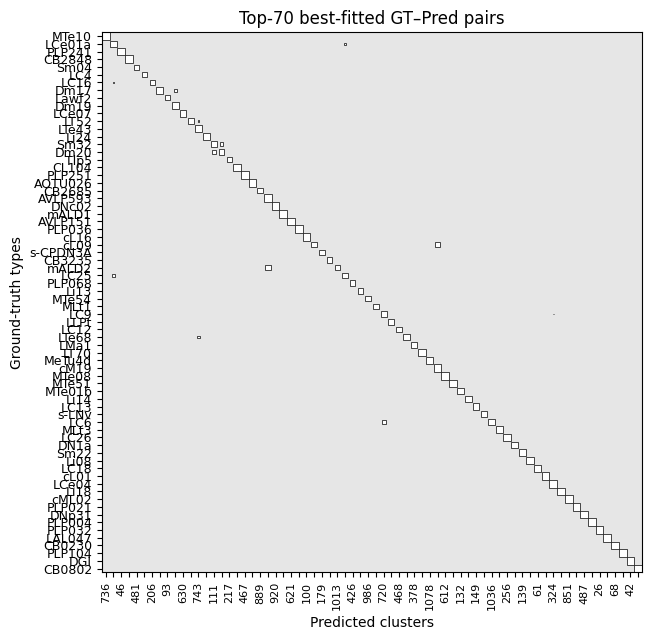

[Saved] Best-match table → wsbm_best_match_9.csv


array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(743, 727))

In [86]:
#1 compute gt
gt_assignments = np.array([cluster_string_to_cid[root_id_type_dict[rid]] for rid in shared_root_ids])



#2 random optimistic label
random_assignment_optimistic = np.random.permutation(gt_assignments)

#3 transfer to continuous int label
y_gt_i, gt_names = make_consecutive_labels(gt_assignments)
y_ro_i, ro_names = make_consecutive_labels(wsbm_assignments)


id_to_string = {v: k for k, v in cluster_string_to_cid.items()}
row_names = [id_to_string[i] for i in range(len(id_to_string))]

plot_hinton_gt_vs_pred(
    y_gt_i, y_ro_i,
    row_names=row_names, col_names=ro_names,
    normalize='row',
    score_metric='f1', 
    top_k_pairs=70,          
    corner='tr',             
    title='Top-70 best-fitted GT–Pred pairs',
    save_csv_path="wsbm_best_match_9.csv",
    save_all_pairs=True
)



=== Top matched GT–Pred pairs ===
Rank | Pred cluster |  GT type |              GT name |  Correct cells |  Cluster size |  GT size |  Purity |  Recall |      F1
-----------------------------------------------------------------------------------------------------------------------------
   1 |          489 |      497 | CB0734               |              1 |             1 |        1 |   1.000 |   1.000 |   1.000
   2 |          228 |      166 | SIP017               |              1 |             1 |        1 |   1.000 |   1.000 |   1.000
   3 |          251 |      478 | PLP217               |              1 |             1 |        1 |   1.000 |   1.000 |   1.000
   4 |          376 |      487 | PLP004               |              1 |             1 |        1 |   1.000 |   1.000 |   1.000
   5 |         1240 |      108 | CB0230               |              1 |             1 |        1 |   1.000 |   1.000 |   1.000
   6 |          507 |      375 | 5-HTPMPV01           |              1 

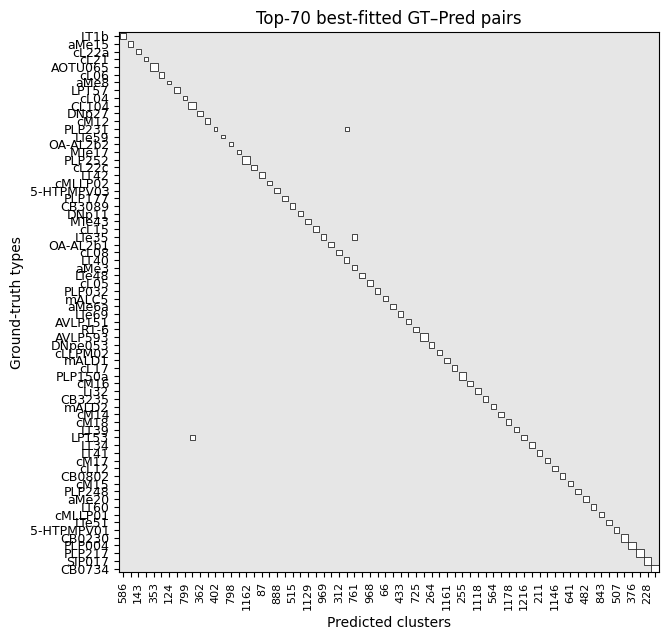

[Saved] Best-match table → pca_top70_best_match.csv


array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0]], shape=(743, 1068))

In [87]:
#1 compute gt
gt_assignments = np.array([cluster_string_to_cid[root_id_type_dict[rid]] for rid in shared_root_ids])

#2 random optimistic label
random_assignment_optimistic = np.random.permutation(gt_assignments)

#3 transfer to continuous int label
y_gt_i, gt_names = make_consecutive_labels(gt_assignments)
y_ro_i, ro_names = make_consecutive_labels(pca_assignments)

plot_hinton_gt_vs_pred(
    y_gt_i, y_ro_i,
    row_names=row_names, col_names=ro_names,
    normalize='row',
    score_metric='f1',
    top_k_pairs=70,
    corner='tr',
    title='Top-70 best-fitted GT–Pred pairs',
    save_csv_path="pca_top70_best_match.csv",
    save_all_pairs=True
)



=== Top matched GT–Pred pairs ===
Rank | Pred cluster |  GT type |              GT name |  Correct cells |  Cluster size |  GT size |  Purity |  Recall |      F1
-----------------------------------------------------------------------------------------------------------------------------
   1 |           74 |      554 | MTe39                |              2 |             3 |        2 |   0.667 |   1.000 |   0.800
   2 |          764 |      518 | LAL047               |              1 |             1 |        2 |   1.000 |   0.500 |   0.667
   3 |          236 |      131 | CB2848               |              1 |             1 |        2 |   1.000 |   0.500 |   0.667
   4 |          411 |       26 | LPT31                |              4 |             5 |        8 |   0.800 |   0.500 |   0.615
   5 |          383 |      276 | LC41                 |              6 |            10 |       12 |   0.600 |   0.500 |   0.545
   6 |          292 |      306 | LTe68                |              5 

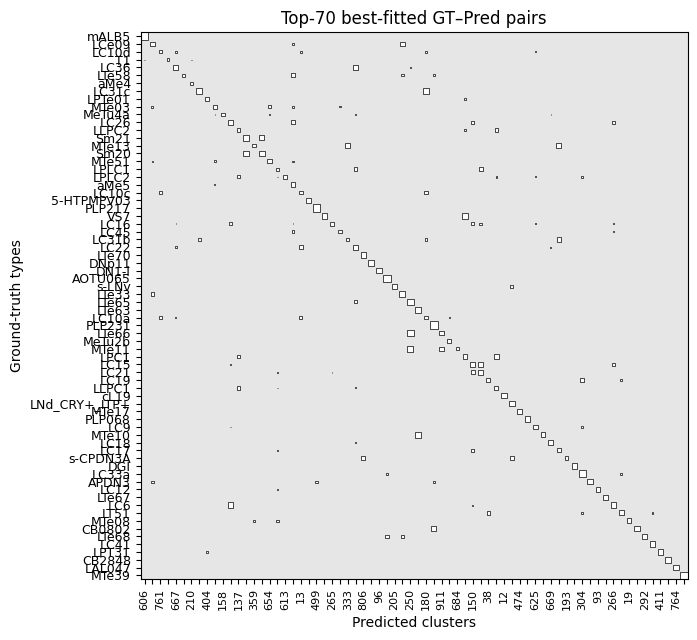

[Saved] Best-match table → lv_top70_best_match.csv


array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 1, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(743, 542))

In [88]:
#1 compute gt
gt_assignments = np.array([cluster_string_to_cid[root_id_type_dict[rid]] for rid in shared_root_ids])

#2 random optimistic label
random_assignment_optimistic = np.random.permutation(gt_assignments)

#3 transfer to continuous int label
y_gt_i, gt_names = make_consecutive_labels(gt_assignments)
y_ro_i, ro_names = make_consecutive_labels(lv_assignments)


plot_hinton_gt_vs_pred(
    y_gt_i, y_ro_i,
    row_names=row_names, col_names=ro_names,
    normalize='row',
    score_metric='f1',
    top_k_pairs=70,
    corner='tr',
    title='Top-70 best-fitted GT–Pred pairs',
    save_csv_path="lv_top70_best_match.csv"
)


In [100]:

import glob

# =========================
# Config
# =========================

CSV_DIR = ""
FILE_PATTERN = "wsbm_best_match_*.csv"

OUT_DIR = "wsbm_type_summary_results"
os.makedirs(OUT_DIR, exist_ok=True)

METRIC = "f1_score"

HIGH_THRESHOLD = 0.50
LOW_THRESHOLD = 0.30

# Avoid tiny GT types producing misleading perfect scores
MIN_GT_SIZE = 0

# A GT type is considered robustly high/low if it appears this many times
ROBUST_HIGH_RUNS = 8
ROBUST_LOW_RUNS = 8


# =========================
# Load all CSV files
# =========================

files = sorted(
    glob.glob(os.path.join(CSV_DIR, FILE_PATTERN)),
    key=lambda x: int(os.path.basename(x).split("_")[-1].split(".")[0])
)

all_dfs = []

for f in files:
    run_id = int(os.path.basename(f).split("_")[-1].split(".")[0])
    df = pd.read_csv(f)
    df["run"] = run_id
    all_dfs.append(df)

all_df = pd.concat(all_dfs, ignore_index=True)

print(f"Loaded {len(files)} files")
print(f"Total rows: {len(all_df)}")
print(all_df.head())


# =========================
# Basic filtering
# =========================

df = all_df.copy()

# Remove very small GT types
df_filtered = df[df["gt_size"] >= MIN_GT_SIZE].copy()

print(f"Rows after gt_size >= {MIN_GT_SIZE}: {len(df_filtered)}")
print(f"Unique GT types after filtering: {df_filtered['gt_type'].nunique()}")


# =========================
# Label high / low accuracy
# =========================

df_filtered["is_high"] = df_filtered[METRIC] >= HIGH_THRESHOLD
df_filtered["is_low"] = df_filtered[METRIC] <= LOW_THRESHOLD

# Optional: middle category
df_filtered["accuracy_group"] = "middle"
df_filtered.loc[df_filtered["is_high"], "accuracy_group"] = "high"
df_filtered.loc[df_filtered["is_low"], "accuracy_group"] = "low"


# =========================
# Summary per GT type
# =========================

summary = (
    df_filtered
    .groupby(["gt_type", "gt_name"])
    .agg(
        n_runs=("run", "nunique"),
        gt_size=("gt_size", "median"),
        mean_score=(METRIC, "mean"),
        std_score=(METRIC, "std"),
        min_score=(METRIC, "min"),
        max_score=(METRIC, "max"),
        median_score=(METRIC, "median"),
        high_runs=("is_high", "sum"),
        low_runs=("is_low", "sum"),
        mean_purity=("purity", "mean"),
        mean_recall=("recall", "mean"),
        mean_f1=("f1_score", "mean"),
        max_f1=("f1_score", "max"),
        mean_correct_cells=("correct_cells", "mean"),
        mean_cluster_size=("cluster_size", "mean"),
    )
    .reset_index()
)

summary["high_frequency"] = summary["high_runs"] / summary["n_runs"]
summary["low_frequency"] = summary["low_runs"] / summary["n_runs"]

summary["category"] = "mixed_or_middle"

summary.loc[
    (summary["high_runs"] >= ROBUST_HIGH_RUNS),
    "category"
] = "robust_high"

summary.loc[
    (summary["low_runs"] >= ROBUST_LOW_RUNS),
    "category"
] = "robust_low"

summary.loc[
    (summary["high_runs"] >= 1) & (summary["high_runs"] < ROBUST_HIGH_RUNS),
    "category"
] = "occasionally_high"

summary.loc[
    (summary["low_runs"] >= 1) & (summary["low_runs"] < ROBUST_LOW_RUNS) & (summary["high_runs"] == 0),
    "category"
] = "occasionally_low"


# Sort by robust high first
summary_sorted = summary.sort_values(
    by=["high_runs", "mean_score", "gt_size"],
    ascending=[False, False, False]
)

summary_path = os.path.join(OUT_DIR, "gt_type_accuracy_summary.csv")
summary_sorted.to_csv(summary_path, index=False)

print(f"Saved summary to: {summary_path}")


# =========================
# Extract useful tables
# =========================

robust_high = summary_sorted[
    summary_sorted["high_runs"] >= ROBUST_HIGH_RUNS
].copy()

robust_low = summary_sorted[
    summary_sorted["low_runs"] >= ROBUST_LOW_RUNS
].copy()

always_high = summary_sorted[
    summary_sorted["high_runs"] == summary_sorted["n_runs"]
].copy()

always_low = summary_sorted[
    summary_sorted["low_runs"] == summary_sorted["n_runs"]
].copy()

occasionally_high = summary_sorted[
    (summary_sorted["high_runs"] >= 1) &
    (summary_sorted["high_runs"] < ROBUST_HIGH_RUNS)
].copy()

mixed = summary_sorted[
    (summary_sorted["high_runs"] >= 1) &
    (summary_sorted["low_runs"] >= 1)
].copy()

tables = {
    "robust_high_types.csv": robust_high,
    "robust_low_types.csv": robust_low,
    "always_high_types.csv": always_high,
    "always_low_types.csv": always_low,
    "occasionally_high_types.csv": occasionally_high,
    "mixed_types_high_and_low.csv": mixed,
}

for name, table in tables.items():
    path = os.path.join(OUT_DIR, name)
    table.to_csv(path, index=False)
    print(f"Saved {name}: {len(table)} rows")


# =========================
# Print top results
# =========================

print("\n===== Robust high GT types =====")
print(
    robust_high[
        ["gt_type", "gt_name", "gt_size", "high_runs", "n_runs", "mean_score", "mean_purity", "mean_recall"]
    ].head(30).to_string(index=False)
)

print("\n===== Robust low GT types =====")
print(
    robust_low[
        ["gt_type", "gt_name", "gt_size", "low_runs", "n_runs", "mean_score", "mean_purity", "mean_recall"]
    ].head(30).to_string(index=False)
)

print("\n===== Always high GT types =====")
print(
    always_high[
        ["gt_type", "gt_name", "gt_size", "high_runs", "n_runs", "mean_score"]
    ].head(30).to_string(index=False)
)

print("\n===== Always low GT types =====")
print(
    always_low[
        ["gt_type", "gt_name", "gt_size", "low_runs", "n_runs", "mean_score"]
    ].head(30).to_string(index=False)
)


# =========================
# Plot 1: high frequency vs mean score
# =========================

plt.figure(figsize=(8, 6))
plt.scatter(
    summary["high_frequency"],
    summary["mean_score"],
    s=np.sqrt(summary["gt_size"]) * 8,
    alpha=0.6
)
plt.axhline(HIGH_THRESHOLD, linestyle="--")
plt.axvline(ROBUST_HIGH_RUNS / len(files), linestyle="--")
plt.xlabel("High-accuracy frequency across runs")
plt.ylabel(f"Mean {METRIC}")
plt.title("GT type robustness: high-accuracy frequency vs mean score")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "high_frequency_vs_mean_score.png"), dpi=300)
plt.close()


# =========================
# Plot 2: low frequency vs mean score
# =========================

plt.figure(figsize=(8, 6))
plt.scatter(
    summary["low_frequency"],
    summary["mean_score"],
    s=np.sqrt(summary["gt_size"]) * 8,
    alpha=0.6
)
plt.axhline(LOW_THRESHOLD, linestyle="--")
plt.axvline(ROBUST_LOW_RUNS / len(files), linestyle="--")
plt.xlabel("Low-accuracy frequency across runs")
plt.ylabel(f"Mean {METRIC}")
plt.title("GT type robustness: low-accuracy frequency vs mean score")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "low_frequency_vs_mean_score.png"), dpi=300)
plt.close()


# =========================
# Plot 3: top robust high types
# =========================

top_high = robust_high.head(30).sort_values("high_runs")

plt.figure(figsize=(10, 8))
plt.barh(top_high["gt_name"], top_high["high_runs"])
plt.xlabel("Number of high-accuracy runs")
plt.ylabel("GT type")
plt.title(f"Top robust high GT types ({METRIC} >= {HIGH_THRESHOLD})")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "top_robust_high_types.png"), dpi=300)
plt.close()


# =========================
# Plot 4: top robust low types
# =========================

top_low = robust_low.sort_values(
    by=["low_runs", "gt_size"],
    ascending=[False, False]
).head(30).sort_values("low_runs")

plt.figure(figsize=(10, 8))
plt.barh(top_low["gt_name"], top_low["low_runs"])
plt.xlabel("Number of low-accuracy runs")
plt.ylabel("GT type")
plt.title(f"Top robust low GT types ({METRIC} <= {LOW_THRESHOLD})")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "top_robust_low_types.png"), dpi=300)
plt.close()


# =========================
# Plot 5: score distribution for robust high types
# =========================

selected_high_names = robust_high.head(20)["gt_name"].tolist()
plot_df = df_filtered[df_filtered["gt_name"].isin(selected_high_names)]

plt.figure(figsize=(12, 6))
plot_df.boxplot(column=METRIC, by="gt_name", rot=90)
plt.suptitle("")
plt.title("Score distribution across runs: robust high GT types")
plt.xlabel("GT type")
plt.ylabel(METRIC)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "robust_high_score_boxplot.png"), dpi=300)
plt.close()


# =========================
# Plot 6: score distribution for robust low types
# =========================

selected_low_names = robust_low.head(20)["gt_name"].tolist()
plot_df = df_filtered[df_filtered["gt_name"].isin(selected_low_names)]

plt.figure(figsize=(12, 6))
plot_df.boxplot(column=METRIC, by="gt_name", rot=90)
plt.suptitle("")
plt.title("Score distribution across runs: robust low GT types")
plt.xlabel("GT type")
plt.ylabel(METRIC)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "robust_low_score_boxplot.png"), dpi=300)
plt.close()


# =========================
# Run-level summary
# =========================

run_summary = (
    df_filtered
    .groupby("run")
    .agg(
        n_types=("gt_type", "nunique"),
        mean_score=(METRIC, "mean"),
        median_score=(METRIC, "median"),
        high_type_count=("is_high", "sum"),
        low_type_count=("is_low", "sum"),
    )
    .reset_index()
)

run_summary_path = os.path.join(OUT_DIR, "run_level_summary.csv")
run_summary.to_csv(run_summary_path, index=False)

print("\n===== Run-level summary =====")
print(run_summary.to_string(index=False))

print(f"\nAll results saved in folder: {OUT_DIR}")

Loaded 10 files
Total rows: 7348
   rank  pred_cluster  gt_type gt_name  correct_cells  cluster_size  purity  \
0     1          1002      415  SIP017              1             1     1.0   
1     2           801      454  CB2580              1             1     1.0   
2     3           760      421   MTe10              8             8     1.0   
3     4           725      274   mALD1              2             2     1.0   
4     5           938      221  PLP021              1             1     1.0   

   gt_size  recall  f1_score  run  
0        1     1.0       1.0    0  
1        1     1.0       1.0    0  
2        8     1.0       1.0    0  
3        2     1.0       1.0    0  
4        1     1.0       1.0    0  
Rows after gt_size >= 0: 7348
Unique GT types after filtering: 743
Saved summary to: wsbm_type_summary_results\gt_type_accuracy_summary.csv
Saved robust_high_types.csv: 34 rows
Saved robust_low_types.csv: 410 rows
Saved always_high_types.csv: 116 rows
Saved always_low_types.c

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

In [ ]:
import seaborn as sns

# =========================
# (Publication-Ready Style)
# =========================
sns.set_theme(style="ticks", context="talk", font_scale=0.9)
# 自定义颜色定义
color_high = "#2a9d8f" 
color_low = "#e76f51"  

# =========================
# Plot 1: high frequency vs mean score
# =========================
plt.figure(figsize=(9, 7))
sns.scatterplot(
    data=summary, 
    x="high_frequency", 
    y="mean_score", 
    size="gt_size", 
    sizes=(20, 600), 
    alpha=0.7, 
    color=color_high,
    edgecolor="white"
)
plt.axhline(HIGH_THRESHOLD, color='gray', linestyle="--", alpha=0.5, zorder=0)
plt.axvline(ROBUST_HIGH_RUNS / len(files), color='gray', linestyle="--", alpha=0.5, zorder=0)

plt.xlabel("Frequency of High-Accuracy Runs", fontweight='bold')
plt.ylabel(f"Mean {METRIC.replace('_', ' ').title()}", fontweight='bold')
plt.title("GT Type Robustness: High-Accuracy Profile", pad=15, fontweight='bold')
plt.legend(title="GT Size", bbox_to_anchor=(1.05, 1), loc='upper left')
sns.despine() 
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "high_frequency_vs_mean_score.png"), dpi=300, bbox_inches='tight')
plt.close()

# =========================
# Plot 2: low frequency vs mean score
# =========================
plt.figure(figsize=(9, 7))
sns.scatterplot(
    data=summary, 
    x="low_frequency", 
    y="mean_score", 
    size="gt_size", 
    sizes=(20, 600), 
    alpha=0.7, 
    color=color_low,
    edgecolor="white"
)
plt.axhline(LOW_THRESHOLD, color='gray', linestyle="--", alpha=0.5, zorder=0)
plt.axvline(ROBUST_LOW_RUNS / len(files), color='gray', linestyle="--", alpha=0.5, zorder=0)

plt.xlabel("Frequency of Low-Accuracy Runs (Fragmentation)", fontweight='bold')
plt.ylabel(f"Mean {METRIC.replace('_', ' ').title()}", fontweight='bold')
plt.title("GT Type Robustness: Low-Accuracy (Fragmentation) Profile", pad=15, fontweight='bold')
plt.legend(title="GT Size", bbox_to_anchor=(1.05, 1), loc='upper left')
sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "low_frequency_vs_mean_score.png"), dpi=300, bbox_inches='tight')
plt.close()

# =========================
# Plot 3: top robust high types (Barplot)
# =========================
top_high = robust_high.head(25).sort_values("high_runs", ascending=False)

plt.figure(figsize=(10, 8))
ax = sns.barplot(
    data=top_high, 
    y="gt_name", 
    x="high_runs", 
    palette=sns.light_palette(color_high, n_colors=len(top_high), reverse=True)
)
plt.xlabel("Number of High-Accuracy Runs", fontweight='bold')
plt.ylabel("GT Type", fontweight='bold')
plt.title(f"Top Robust High GT Types ({METRIC} ≥ {HIGH_THRESHOLD})", pad=15, fontweight='bold')
sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "top_robust_high_types.png"), dpi=300)
plt.close()

# =========================
# Plot 4: top robust low types (Barplot)
# =========================
top_low = robust_low.sort_values(
    by=["low_runs", "gt_size"], 
    ascending=[False, False]
).head(25)

plt.figure(figsize=(10, 8))
sns.barplot(
    data=top_low, 
    y="gt_name", 
    x="low_runs", 
    palette=sns.light_palette(color_low, n_colors=len(top_low), reverse=True)
)
plt.xlabel("Number of Low-Accuracy Runs", fontweight='bold')
plt.ylabel("GT Type", fontweight='bold')
plt.title(f"Top Robust Low (Fragmented) GT Types ({METRIC} ≤ {LOW_THRESHOLD})", pad=15, fontweight='bold')
sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "top_robust_low_types.png"), dpi=300)
plt.close()

# =========================
# Plot 5: score distribution for robust high types (Boxplot + Stripplot)
# =========================
selected_high_names = robust_high.head(20)["gt_name"].tolist()
plot_df_high = df_filtered[df_filtered["gt_name"].isin(selected_high_names)]
# 按照中位数排序，让图表呈阶梯状下降，非常美观
order_high = plot_df_high.groupby("gt_name")[METRIC].median().sort_values(ascending=False).index

plt.figure(figsize=(14, 6))
# 绘制半透明的箱线图
sns.boxplot(
    data=plot_df_high, x="gt_name", y=METRIC, order=order_high, 
    color=color_high, boxprops=dict(alpha=0.4), showfliers=False
)
# 叠加实际的 run 点，看清楚 9 次分布的具体位置
sns.stripplot(
    data=plot_df_high, x="gt_name", y=METRIC, order=order_high, 
    color=color_high, alpha=0.8, jitter=True, size=6
)
plt.xticks(rotation=45, ha="right")
plt.xlabel("GT Type", fontweight='bold')
plt.ylabel(METRIC.replace('_', ' ').title(), fontweight='bold')
plt.title("Run-level Consistency: Robust High GT Types", pad=15, fontweight='bold')
sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "robust_high_score_boxplot.png"), dpi=300)
plt.close()

# =========================
# Plot 6: score distribution for robust low types (Boxplot + Stripplot)
# =========================
selected_low_names = robust_low.head(20)["gt_name"].tolist()
plot_df_low = df_filtered[df_filtered["gt_name"].isin(selected_low_names)]
order_low = plot_df_low.groupby("gt_name")[METRIC].median().sort_values(ascending=False).index

plt.figure(figsize=(14, 6))
sns.boxplot(
    data=plot_df_low, x="gt_name", y=METRIC, order=order_low, 
    color=color_low, boxprops=dict(alpha=0.4), showfliers=False
)
sns.stripplot(
    data=plot_df_low, x="gt_name", y=METRIC, order=order_low, 
    color=color_low, alpha=0.8, jitter=True, size=6
)
plt.xticks(rotation=45, ha="right")
plt.xlabel("GT Type", fontweight='bold')
plt.ylabel(METRIC.replace('_', ' ').title(), fontweight='bold')
plt.title("Run-level Consistency: Robust Low (Fragmented) GT Types", pad=15, fontweight='bold')
sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "robust_low_score_boxplot.png"), dpi=300)
plt.close()

# =========================
# Run-level summary
# =========================
run_summary = (
    df_filtered
    .groupby("run")
    .agg(
        n_types=("gt_type", "nunique"),
        mean_score=(METRIC, "mean"),
        median_score=(METRIC, "median"),
        high_type_count=("is_high", "sum"),
        low_type_count=("is_low", "sum"),
    )
    .reset_index()
)

run_summary_path = os.path.join(OUT_DIR, "run_level_summary.csv")
run_summary.to_csv(run_summary_path, index=False)

print("\n===== Run-level summary =====")
print(run_summary.to_string(index=False))

print(f"\nAll visualization plots saved in folder: {OUT_DIR}")

C:\Users\ROG\AppData\Local\Temp\ipykernel_21668\1059950363.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
C:\Users\ROG\AppData\Local\Temp\ipykernel_21668\1059950363.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(



===== Run-level summary =====
 run  n_types  mean_score  median_score  high_type_count  low_type_count
   0      740    0.181188      0.000000               89             542
   1      731    0.180302      0.000000               92             536
   2      731    0.180302      0.000000               92             536
   3      720    0.184118      0.000000               91             524
   4      727    0.187907      0.000000               95             531
   5      743    0.206745      0.008734              118             511
   6      743    0.183152      0.000000               93             538
   7      743    0.191204      0.000000               97             536
   8      743    0.185342      0.000000               90             536
   9      727    0.190389      0.000000               99             515

All visualization plots saved in folder: wsbm_type_summary_results


In [111]:
root_id_type_dict

{720575940596125868: 'T5c',
 720575940597856265: 'Tm16',
 720575940597944841: 'Tm7',
 720575940598267657: 'TmY15',
 720575940599333574: 'Tm1',
 720575940599457990: 'T4b',
 720575940599459782: 'T5b',
 720575940599704006: 'T5a',
 720575940599729862: 'T5a',
 720575940599733446: 'T5b',
 720575940599736492: 'R1-6',
 720575940599744172: 'R1-6',
 720575940599755718: 'T4a',
 720575940599763910: 'T5b',
 720575940599797164: 'Dm3v',
 720575940600010668: 'R1-6',
 720575940600071689: 'T5b',
 720575940600084489: 'Tm9',
 720575940600101641: 'T4a',
 720575940600124169: 'T5b',
 720575940600143369: 'T4a',
 720575940600150793: 'T5a',
 720575940600322965: 'L2',
 720575940600547529: 'T4a',
 720575940600588204: 'Dm2',
 720575940600623020: 'Dm3q',
 720575940600722348: 'Sm01',
 720575940600782252: 'Mi9',
 720575940600850441: 'T4c',
 720575940600866569: 'T5d',
 720575940600934665: 'T4d',
 720575940601049097: 'R1-6',
 720575940601067436: 'Mi15',
 720575940601103625: 'TmY3',
 720575940601206499: 'T4b',
 72057594

In [ ]:
neuron_id = 720575940629970489

print(root_id_type_dict[neuron_id])

L2


In [ ]:
df_conn = pd.read_csv('connections.csv.gz')

In [127]:
a = df_conn[df_conn["neuropil"].isin(["AME_R", "LA_R", "LO_R", "LOP_R", "ME_R"])]
a

,pre_root_id,post_root_id,neuropil,syn_count,nt_type
15,720575940620963920,720575940619093761,LA_R,4,ACH
80,720575940618003929,720575940637157232,LA_R,15,GLUT
301,720575940634729241,720575940623664664,LA_R,6,GLUT
593,720575940660573313,720575940617301691,LA_R,15,ACH
642,720575940612531921,720575940622728157,LA_R,11,ACH
...,...,...,...,...,...
16847985,720575940630831738,720575940616722393,ME_R,1,GLUT
16847988,720575940615147020,720575940639385149,ME_R,1,GABA
16847989,720575940624226244,720575940625584627,ME_R,2,GABA
16847993,720575940624016823,720575940622760993,ME_R,4,ACH


In [129]:
a['gt_name'] = a['pre_root_id'].map(root_id_type_dict)
a

C:\Users\ROG\AppData\Local\Temp\ipykernel_21668\3454827722.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  a['gt_name'] = a['pre_root_id'].map(root_id_type_dict)


,pre_root_id,post_root_id,neuropil,syn_count,nt_type,gt_name
15,720575940620963920,720575940619093761,LA_R,4,ACH,Lawf2
80,720575940618003929,720575940637157232,LA_R,15,GLUT,R1-6
301,720575940634729241,720575940623664664,LA_R,6,GLUT,R1-6
593,720575940660573313,720575940617301691,LA_R,15,ACH,Lawf2
642,720575940612531921,720575940622728157,LA_R,11,ACH,C2
...,...,...,...,...,...,...
16847985,720575940630831738,720575940616722393,ME_R,1,GLUT,Tm4
16847988,720575940615147020,720575940639385149,ME_R,1,GABA,TmY15
16847989,720575940624226244,720575940625584627,ME_R,2,GABA,Sm08
16847993,720575940624016823,720575940622760993,ME_R,4,ACH,TmY10


In [ ]:
df_conn[df_conn['pre_root_id'] == 720575940629970489]

,pre_root_id,post_root_id,neuropil,syn_count,nt_type
0,720575940629970489,720575940631267655,AVLP_R,7,GABA
2638,720575940629970489,720575940620005542,AVLP_R,16,GABA
2800,720575940629970489,720575940626081319,AVLP_R,7,GABA
4934,720575940629970489,720575940652258806,AVLP_R,5,GABA
4985,720575940629970489,720575940624508563,AVLP_R,21,GABA
...,...,...,...,...,...
16753131,720575940629970489,720575940640023886,PVLP_R,5,GABA
16756383,720575940629970489,720575940612125923,PVLP_R,1,OCT
16782363,720575940629970489,720575940627710470,AVLP_R,1,GABA
16787415,720575940629970489,720575940645697668,AVLP_R,2,GABA


In [121]:
root_id_type_dict

{720575940596125868: 'T5c',
 720575940597856265: 'Tm16',
 720575940597944841: 'Tm7',
 720575940598267657: 'TmY15',
 720575940599333574: 'Tm1',
 720575940599457990: 'T4b',
 720575940599459782: 'T5b',
 720575940599704006: 'T5a',
 720575940599729862: 'T5a',
 720575940599733446: 'T5b',
 720575940599736492: 'R1-6',
 720575940599744172: 'R1-6',
 720575940599755718: 'T4a',
 720575940599763910: 'T5b',
 720575940599797164: 'Dm3v',
 720575940600010668: 'R1-6',
 720575940600071689: 'T5b',
 720575940600084489: 'Tm9',
 720575940600101641: 'T4a',
 720575940600124169: 'T5b',
 720575940600143369: 'T4a',
 720575940600150793: 'T5a',
 720575940600322965: 'L2',
 720575940600547529: 'T4a',
 720575940600588204: 'Dm2',
 720575940600623020: 'Dm3q',
 720575940600722348: 'Sm01',
 720575940600782252: 'Mi9',
 720575940600850441: 'T4c',
 720575940600866569: 'T5d',
 720575940600934665: 'T4d',
 720575940601049097: 'R1-6',
 720575940601067436: 'Mi15',
 720575940601103625: 'TmY3',
 720575940601206499: 'T4b',
 72057594

In [135]:
df_conn

,pre_root_id,post_root_id,neuropil,syn_count,nt_type,gt_name
0,720575940629970489,720575940631267655,AVLP_R,7,GABA,NaN
1,720575940623828999,720575940612348950,SLP_R,4,GLUT,NaN
2,720575940624078484,720575940616950161,SMP_R,2,ACH,NaN
3,720575940629583345,720575940620324735,SMP_L,2,GLUT,NaN
4,720575940605876866,720575940606514878,LAL_R,15,GABA,NaN
...,...,...,...,...,...,...
16847992,720575940615769750,720575940622822680,AVLP_L,1,ACH,NaN
16847993,720575940624016823,720575940622760993,ME_R,4,ACH,TmY10
16847994,720575940637397309,720575940633255123,SLP_R,2,GABA,NaN
16847995,720575940636432014,720575940617470681,ME_R,1,GLUT,Mi14


In [ ]:
import pandas as pd
import pickle

# 1. 加载你的字典
root_id_type_dict = pickle.load(open('root_id_type_dict.pkl', 'rb'))

# 2. 读取连接数据 (pandas 会自动处理 .gz)
df_conn = pd.read_csv('connections.csv.gz')

# 3. 将字典映射到连接表上
# 我们查看突触前神经元 (pre_root_id) 属于哪个 GT 类型
df_conn['gt_name'] = df_conn['pre_root_id'].map(root_id_type_dict)

# 4. 统计特定 GT Type 的脑区分布
# 比如你想看 'LC16' 的分布
target_type = 'LC16'
lc16_distribution = df_conn[df_conn['gt_name'] == target_type].groupby('neuropil')['syn_count'].sum().sort_values(ascending=False)

print(f"--- {target_type} 的脑区分布 (按突触数量排序) ---")
print(lc16_distribution)

# 5. 如果想看所有常用 GT Type 的主要脑区（前3名）
summary = df_conn.groupby(['gt_name', 'neuropil'])['syn_count'].sum().reset_index()
summary = summary.sort_values(['gt_name', 'syn_count'], ascending=[True, False])
top_neuropils = summary.groupby('gt_name').head(3)

print("\n--- 各 GT 类型的主要脑区 ---")
print(top_neuropils.head(20))

--- LC16 的脑区分布 (按突触数量排序) ---
neuropil
PVLP_L    21738
PVLP_R    18919
AVLP_R     7472
LO_L       4594
LO_R       3944
AVLP_L     1078
PLP_L       326
PLP_R        37
LH_L          2
ICL_L         1
WED_L         1
Name: syn_count, dtype: int64

--- 各 GT 类型的主要脑区 ---
          gt_name neuropil  syn_count
14     5-HTPMPV01    PLP_L        294
15     5-HTPMPV01    PLP_R        171
6      5-HTPMPV01    ICL_L        112
55     5-HTPMPV03     ME_R       1200
54     5-HTPMPV03     ME_L        862
51     5-HTPMPV03     LO_L        395
86        5th-LNv    SMP_R        368
85        5th-LNv    SMP_L        353
72        5th-LNv    AME_R         85
113  AN_multi_124     LO_L        156
101  AN_multi_124      GNG        136
92   AN_multi_124   AVLP_R        115
163  AN_multi_125     ME_L        134
162  AN_multi_125     LO_R        105
164  AN_multi_125     ME_R         64
180       AOTU026    LAL_R        739
185       AOTU026    SPS_R        508
186       AOTU026    VES_R        279
188       AO

In [189]:
plot_df.to_csv('high_accuracy_neuropil.csv', index=False)

<Figure size 1200x1000 with 0 Axes>

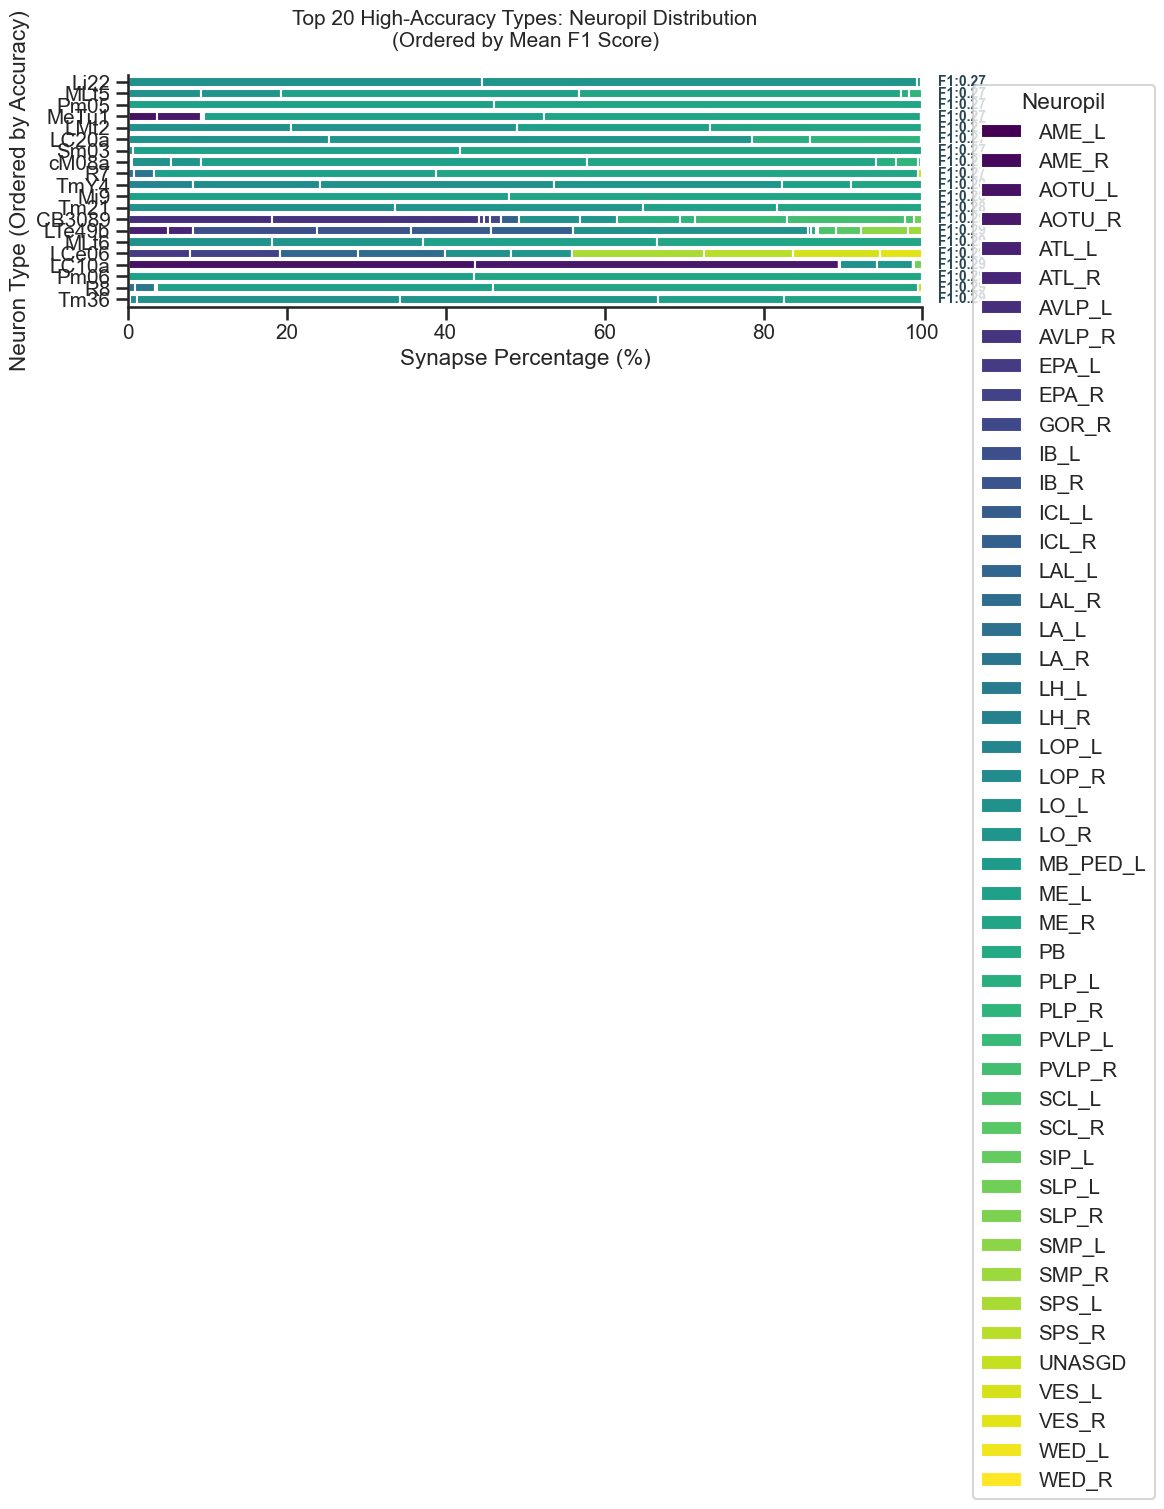

In [ ]:
import pandas as pd
import pickle
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 加载 High Accuracy 评分表并取前 20
high_df = pd.read_csv('wsbm_type_summary_results/always_high_types.csv')
# 确保按 mean_score 降序排列
top_20_high = high_df.sort_values('mean_score', ascending=False).head(20)
target_names = top_20_high['gt_name'].tolist()

# 2. 加载字典
root_id_type_dict = pickle.load(open('root_id_type_dict.pkl', 'rb'))

# 3. 处理连接数据
df_conn = pd.read_csv('connections.csv.gz')
df_conn['gt_name'] = df_conn['pre_root_id'].map(root_id_type_dict)

# 4. 过滤并计算百分比
# 只看这 Top 20 的类型
df_filtered = df_conn[df_conn['gt_name'].isin(target_names)]
dist = df_filtered.groupby(['gt_name', 'neuropil'])['syn_count'].sum().reset_index()

# 计算百分比
totals = dist.groupby('gt_name')['syn_count'].transform('sum')
dist['percentage'] = (dist['syn_count'] / totals) * 100

# 5. 准备绘图数据：将 neuropil 展开为列（Pivot）
plot_df = dist.pivot(index='gt_name', columns='neuropil', values='percentage').fillna(0)

# 【核心步】按照 Accuracy 的顺序重新排序 Index
plot_df = plot_df.reindex(target_names)

# 6. 可视化
plt.figure(figsize=(12, 10))
# 使用水平堆叠柱状图避免标签重叠
ax = plot_df.plot(kind='barh', stacked=True, figsize=(12, 10), colormap='viridis', width=0.8)

# 在图右侧标注具体的 F1 Score
for i, name in enumerate(target_names):
    score = top_20_high[top_20_high['gt_name'] == name]['mean_score'].values[0]
    plt.text(102, i, f"F1:{score:.2f}", va='center', fontsize=10, fontweight='bold', color='#264653')

plt.title("Top 20 High-Accuracy Types: Neuropil Distribution\n(Ordered by Mean F1 Score)", fontsize=15, pad=20)
plt.xlabel("Synapse Percentage (%)")
plt.ylabel("Neuron Type (Ordered by Accuracy)")
plt.legend(title="Neuropil", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlim(0, 100)
sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import pickle

# 1. 加载 Top 20 列表
high_types = pd.read_csv('wsbm_type_summary_results/always_high_types.csv').head(20)['gt_name'].tolist()
low_types = pd.read_csv('wsbm_type_summary_results/always_low_types.csv').head(20)['gt_name'].tolist()
all_targets = high_types + low_types

# 2. 加载 ID-类型 映射字典
with open('root_id_type_dict.pkl', 'rb') as f:
    id_to_type = pickle.load(f)

# 3. 读取连接数据（建议只读取需要的列以节省内存）
# 我们关注 pre_root_id (出发点) 和 neuropil (所在地)
print("正在读取连接组数据...")
df_conn = pd.read_csv('connections.csv.gz', usecols=['pre_root_id', 'syn_count', 'neuropil'])

# 4. 映射类型标签
df_conn['gt_name'] = df_conn['pre_root_id'].map(id_to_type)

# 5. 过滤出目标 Top 40 类型，并计算脑区分布
# filtered_df = df_conn[df_conn['gt_name'].isin(low_types)]
filtered_df = df_conn[df_conn['gt_name'].isin(high_types)]


dist = filtered_df.groupby(['gt_name', 'neuropil'])['syn_count'].sum().reset_index()

# 计算百分比 (每个类型在各脑区的突触占比)
dist['percentage'] = dist.groupby('gt_name')['syn_count'].transform(lambda x: (x / x.sum()) * 100)

# 6. 提取每个类型最主要的 Top 3 脑区
top_3_per_type = dist.sort_values(['gt_name', 'syn_count'], ascending=[True, False]).groupby('gt_name').head(3)

# 7. 打印结果
print("\n===== Always High Types (前20) 主要脑区分布 =====")
print(top_3_per_type[top_3_per_type['gt_name'].isin(high_types)])

print("\n===== Always Low Types (前20) 主要脑区分布 =====")
print(top_3_per_type[top_3_per_type['gt_name'].isin(low_types)])

# 保存结果供后续画图
top_3_per_type.to_csv('top_40_types_neuropil_top3.csv', index=False)

正在读取连接组数据...

===== Always High Types (前20) 主要脑区分布 =====
Empty DataFrame
Columns: [gt_name, neuropil, syn_count, percentage]
Index: []

===== Always Low Types (前20) 主要脑区分布 =====
    gt_name neuropil  syn_count  percentage
1    CB3089   AVLP_R         95   26.098901
0    CB3089   AVLP_L         66   18.131868
11   CB3089   PVLP_R         54   14.835165
15    LC10a   AOTU_R      35032   45.783290
14    LC10a   AOTU_L      33417   43.672648
22    LC10a     LO_L       3580    4.678699
37    LC20a     LO_R       6361   53.216766
36    LC20a     LO_L       3003   25.123400
39    LC20a    PLP_R       1680   14.055049
49    LCe06    SPS_L        772   16.587881
42    LCe06    EPA_R        529   11.366566
50    LCe06    SPS_R        522   11.216158
57     LMt2     LO_R      15800   28.437213
59     LMt2     ME_R      14842   26.712982
58     LMt2     ME_L      13506   24.308418
70   LTe49b     LO_L        480   29.520295
66   LTe49b     IB_L        253   15.559656
67   LTe49b     IB_R        19

<Figure size 1200x600 with 0 Axes>

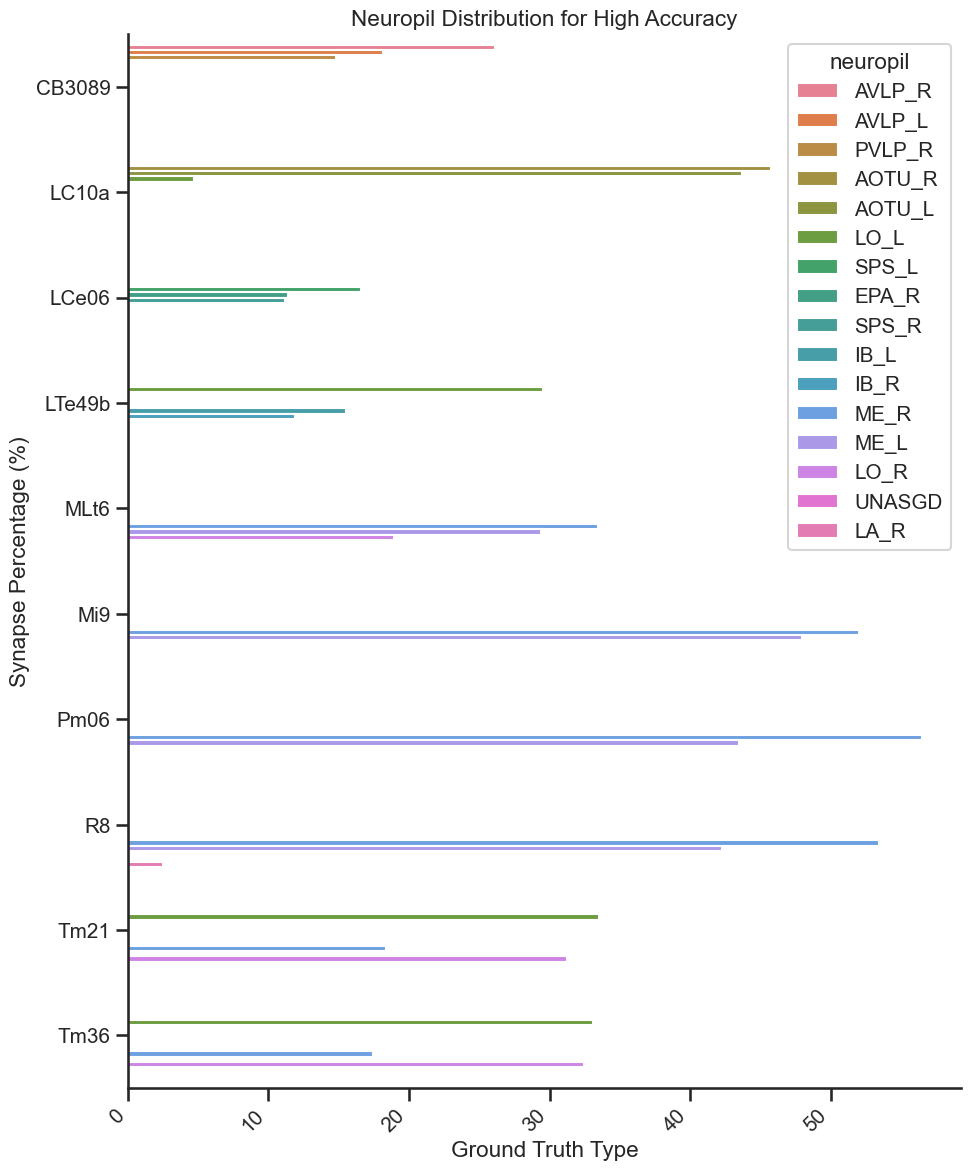

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 假设你已经运行了上一段代码得到了 top_40_types_neuropil_top3.csv
df_plot = pd.read_csv('top_40_types_neuropil_top3.csv')

# 选取展示对象
# sample_types = low_types[:10]
sample_types = high_types[:10]


df_sample = df_plot[df_plot['gt_name'].isin(sample_types)]

# 绘图
plt.figure(figsize=(12, 6))
plt.figure(figsize=(10, 12))
sns.barplot(data=df_sample, y='gt_name', x='percentage', hue='neuropil', orient='h')
plt.xticks(rotation=45, ha='right')
plt.title("Neuropil Distribution for High Accuracy")
plt.ylabel("Synapse Percentage (%)")
plt.xlabel("Ground Truth Type")
sns.despine()
plt.tight_layout()
plt.savefig("neuropil_fingerprint_compare.png", dpi=300)

In [191]:
import pandas as pd

# ===== 1. read data =====
df = pd.read_csv("high_accuracy_neuropil.csv")

# ===== 2. neuropil -> larger category mapping =====
category_map = {
    # Optic Lobe
    "AME": "Optic Lobe",
    "LA": "Optic Lobe",
    "LO": "Optic Lobe",
    "LOP": "Optic Lobe",
    "ME": "Optic Lobe",

    # Lateral Complex
    "BU": "Lateral Complex",
    "LAL": "Lateral Complex",
    "GA": "Lateral Complex",

    # Lateral Horn
    "LH": "Lateral Horn",

    # Periesophageal Neuropils
    "CAN": "Periesophageal Neuropils",
    "AMMC": "Periesophageal Neuropils",
    "FLA": "Periesophageal Neuropils",
    "SAD": "Periesophageal Neuropils",
    "PRW": "Periesophageal Neuropils",

    # Inferior Neuropils
    "ICL": "Inferior Neuropils",
    "IB": "Inferior Neuropils",
    "ATL": "Inferior Neuropils",
    "CRE": "Inferior Neuropils",
    "SCL": "Inferior Neuropils",

    # Ventromedial Neuropils
    "VES": "Ventromedial Neuropils",
    "GOR": "Ventromedial Neuropils",
    "SPS": "Ventromedial Neuropils",
    "IPS": "Ventromedial Neuropils",
    "EPA": "Ventromedial Neuropils",

    # Mushroom Body
    "MB_PED": "Mushroom Body",
    "MB_VL": "Mushroom Body",
    "MB_ML": "Mushroom Body",
    "MB_CA": "Mushroom Body",

    # Antennal Lobe
    "AL": "Antennal Lobe",

    # Superior Neuropils
    "SLP": "Superior Neuropils",
    "SIP": "Superior Neuropils",
    "SMP": "Superior Neuropils",

    # Ventrolateral Neuropils
    "AVLP": "Ventrolateral Neuropils",
    "PVLP": "Ventrolateral Neuropils",
    "WED": "Ventrolateral Neuropils",
    "PLP": "Ventrolateral Neuropils",
    "AOTU": "Ventrolateral Neuropils",

    # Central
    "NO": "Central Complex",
    "PB": "Central Complex",
    "EB": "Central Complex",
    "FB": "Central Complex",

    # Other center regions
    "GNG": "Gnathal Ganglia",
    "OCG": "Ocelli",
    "UNASGD": "Other Regions",
}

# ===== 3. function: remove side suffix =====
def get_base_neuropil(col):
    """
    Examples:
    AME_L -> AME
    AME_R -> AME
    MB_CA_L -> MB_CA
    GNG -> GNG
    """
    if col.endswith("_L") or col.endswith("_R"):
        return col[:-2]
    return col

# ===== 4. aggregate columns by large category =====
large_category_df = pd.DataFrame(index=df.index)

unmapped = []

for col in df.columns:
    base = get_base_neuropil(col)

    if base in category_map:
        category = category_map[base]

        if category not in large_category_df.columns:
            large_category_df[category] = 0.0

        large_category_df[category] += df[col]
    else:
        unmapped.append(col)

# ===== 5. save result =====
large_category_df.to_csv("high_accuracy_neuropil_large_categories.csv", index=False)

print("Saved to high_accuracy_neuropil_large_categories.csv")
print("New columns:")
print(large_category_df.columns.tolist())

if unmapped:
    print("\nUnmapped columns:")
    print(unmapped)

Saved to high_accuracy_neuropil_large_categories.csv
New columns:
['Optic Lobe', 'Ventrolateral Neuropils', 'Inferior Neuropils', 'Ventromedial Neuropils', 'Lateral Complex', 'Lateral Horn', 'Mushroom Body', 'Central Complex', 'Superior Neuropils', 'Other Regions']


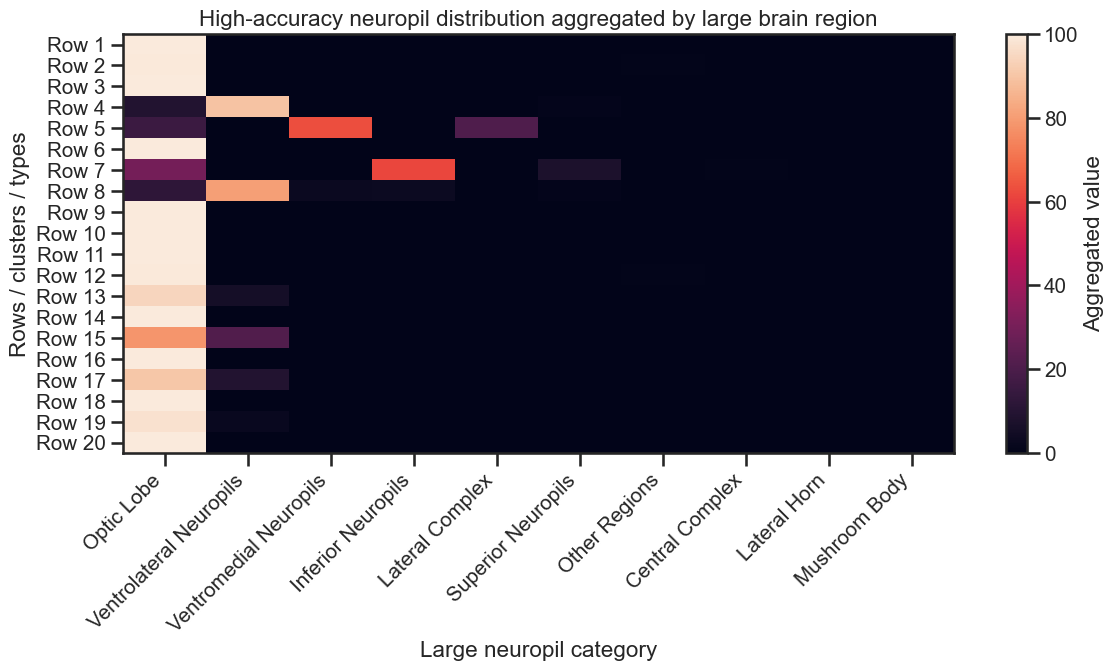

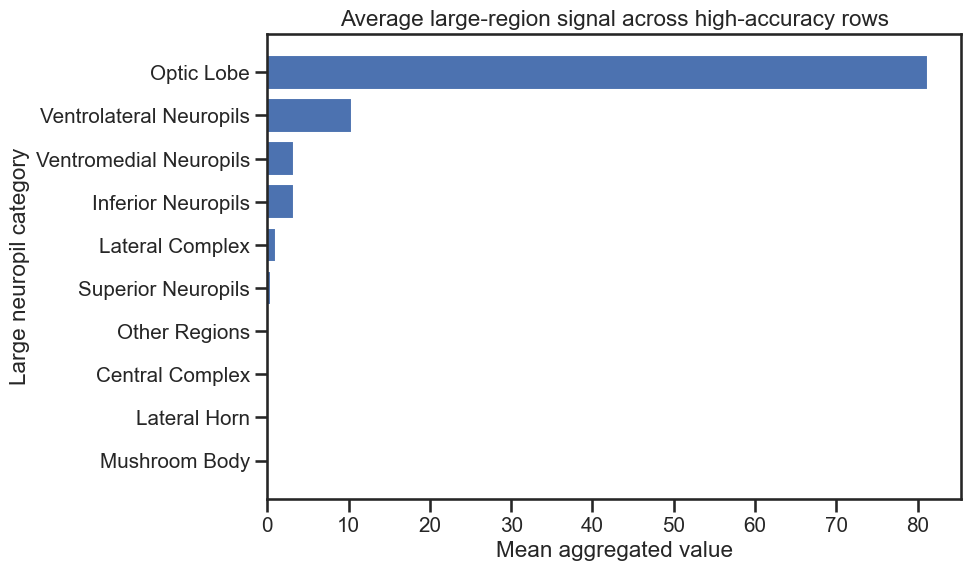

C:\Users\ROG\AppData\Local\Temp\ipykernel_21668\1423091800.py:84: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(norm_df.index, rotation=45, ha="right")


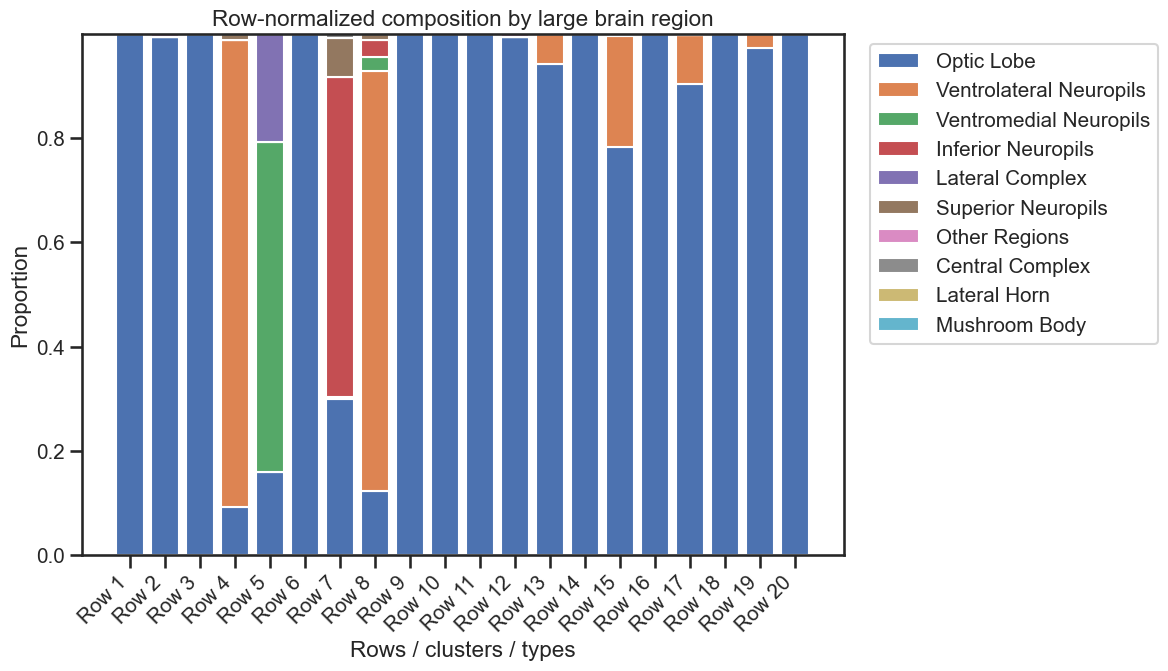

Saved files:
high_accuracy_neuropil_large_categories.csv
high_accuracy_large_category_heatmap.png
high_accuracy_large_category_mean_bar.png
high_accuracy_large_category_stacked_bar.png
Unmapped columns: []


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

csv_path = Path("high_accuracy_neuropil.csv")
df = pd.read_csv(csv_path)

category_map = {
    "AME": "Optic Lobe", "LA": "Optic Lobe", "LO": "Optic Lobe", "LOP": "Optic Lobe", "ME": "Optic Lobe",
    "BU": "Lateral Complex", "LAL": "Lateral Complex", "GA": "Lateral Complex",
    "LH": "Lateral Horn",
    "CAN": "Periesophageal Neuropils", "AMMC": "Periesophageal Neuropils", "FLA": "Periesophageal Neuropils",
    "SAD": "Periesophageal Neuropils", "PRW": "Periesophageal Neuropils",
    "ICL": "Inferior Neuropils", "IB": "Inferior Neuropils", "ATL": "Inferior Neuropils", "CRE": "Inferior Neuropils", "SCL": "Inferior Neuropils",
    "VES": "Ventromedial Neuropils", "GOR": "Ventromedial Neuropils", "SPS": "Ventromedial Neuropils", "IPS": "Ventromedial Neuropils", "EPA": "Ventromedial Neuropils",
    "MB_PED": "Mushroom Body", "MB_VL": "Mushroom Body", "MB_ML": "Mushroom Body", "MB_CA": "Mushroom Body",
    "AL": "Antennal Lobe",
    "SLP": "Superior Neuropils", "SIP": "Superior Neuropils", "SMP": "Superior Neuropils",
    "AVLP": "Ventrolateral Neuropils", "PVLP": "Ventrolateral Neuropils", "WED": "Ventrolateral Neuropils", "PLP": "Ventrolateral Neuropils", "AOTU": "Ventrolateral Neuropils",
    "NO": "Central Complex", "PB": "Central Complex", "EB": "Central Complex", "FB": "Central Complex",
    "GNG": "Gnathal Ganglia", "OCG": "Ocelli", "UNASGD": "Other Regions",
}

def get_base_neuropil(col):
    return col[:-2] if col.endswith(("_L", "_R")) else col

large_df = pd.DataFrame(index=df.index)
unmapped = []
for col in df.columns:
    base = get_base_neuropil(col)
    cat = category_map.get(base)
    if cat is None:
        unmapped.append(col)
        continue
    if cat not in large_df:
        large_df[cat] = 0.0
    large_df[cat] += df[col]

# Sort columns by total signal
large_df = large_df[large_df.sum().sort_values(ascending=False).index]
large_df.index = [f"Row {i+1}" for i in range(len(large_df))]

out_csv = Path("high_accuracy_neuropil_large_categories.csv")
large_df.to_csv(out_csv)

# 1. Heatmap
fig, ax = plt.subplots(figsize=(12, 7))
im = ax.imshow(large_df.values, aspect="auto")
ax.set_xticks(range(len(large_df.columns)))
ax.set_xticklabels(large_df.columns, rotation=45, ha="right")
ax.set_yticks(range(len(large_df.index)))
ax.set_yticklabels(large_df.index)
ax.set_title("High-accuracy neuropil distribution aggregated by large brain region")
ax.set_xlabel("Large neuropil category")
ax.set_ylabel("Rows / clusters / types")
fig.colorbar(im, ax=ax, label="Aggregated value")
fig.tight_layout()
heatmap_path = Path("high_accuracy_large_category_heatmap.png")
fig.savefig(heatmap_path, dpi=200, bbox_inches="tight")
plt.show()

# 2. Mean bar plot
mean_vals = large_df.mean().sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(mean_vals.index, mean_vals.values)
ax.set_title("Average large-region signal across high-accuracy rows")
ax.set_xlabel("Mean aggregated value")
ax.set_ylabel("Large neuropil category")
fig.tight_layout()
bar_path = Path("high_accuracy_large_category_mean_bar.png")
fig.savefig(bar_path, dpi=200, bbox_inches="tight")
plt.show()

# 3. Row-normalized stacked bar
norm_df = large_df.div(large_df.sum(axis=1).replace(0, pd.NA), axis=0).fillna(0)
fig, ax = plt.subplots(figsize=(12, 7))
bottom = pd.Series([0.0] * len(norm_df), index=norm_df.index)
for col in norm_df.columns:
    ax.bar(norm_df.index, norm_df[col], bottom=bottom, label=col)
    bottom += norm_df[col]
ax.set_title("Row-normalized composition by large brain region")
ax.set_xlabel("Rows / clusters / types")
ax.set_ylabel("Proportion")
ax.set_xticklabels(norm_df.index, rotation=45, ha="right")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
stacked_path = Path("high_accuracy_large_category_stacked_bar.png")
fig.savefig(stacked_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved files:")
print(out_csv)
print(heatmap_path)
print(bar_path)
print(stacked_path)
print("Unmapped columns:", unmapped)
